In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import simps
from numpy import trapz
from scipy.optimize import curve_fit
from scipy.stats import rayleigh
from concurrent.futures import ThreadPoolExecutor
from scipy.optimize import curve_fit
from scipy import integrate
import matplotlib.ticker as mtick
from matplotlib.ticker import FormatStrFormatter
import matplotlib as mpl
from scipy import integrate
from scipy.signal import find_peaks
import sys
import os 

In [2]:
def gaussian1(x,  norm1,mean1,sigma1):
    return (norm1/(sigma1*np.sqrt(2*np.pi)))*np.exp(-np.power(x - mean1, 2)/(2*np.power(sigma1, 2)))
    #return norm1*np.exp(-np.power(x - mean1, 2)/(2*np.power(sigma1, 2)))
    
def linear(x,slope,intercept):
    return slope*x + intercept 
    
def fitFunc_1(x,norm1,mean1,sigma1,slope,intercept):
    return gaussian1(x, norm1,mean1,sigma1) + linear(x,slope,intercept)     
    
    
def quadratic(x,a,b,c):
    return a*x**2 + b*x + c
def fitFunc(x, norm1,mean1,sigma1,a,b,c):
    return  gaussian1(x, norm1,mean1,sigma1) + quadratic(x,a,b,c) 

In [3]:
runNumber = np.array([1551, 1552, 1553, 1554, 1555, 1556, 1557, 1558, 1559, 1560, 1561,
       1562, 1563, 1564, 1565, 1566, 1567, 1568, 1569, 1570])

In [4]:
Charge= np.array([106453.0, 47702.0, 41082.0, 105525.0, 41106.0, 40617.0, 40744.0,
       39717.0, 38926.0, 40146.0, 37796.0, 37319.0, 37509.0, 35812.0,
       34196.0, 33325.0, 34369.0, 35934.0, 39085.0, 34647.0])

In [5]:
Energy = np.array([809.8835707035981, 804.9714471774502, 801.2135401600046,
       799.0471372340384, 797.2419823087131, 794.932882040955,
       792.7996377466193, 791.1123391530667, 788.7138097169803,
       786.5030146513335, 784.6998337048979, 782.837496262234,
       781.3320928443702, 779.9625792824354, 778.801879934974,
       777.6054325839865, 776.4464891081052, 775.8490561254772,
       775.264038596197, 774.7523292560198])

In [6]:
datafile = np.loadtxt("/Users/shahinashahina/Documents/PhD/Experiments/25Mg(a,n)/CAMPAIGN_2021/25Mg_CAMPAIGN_2021/Data/25Mgan_Nov_Dec_2021_CeBr3/run_1556.mpa", skiprows=323)

In [7]:
y_data = datafile
y_data_err = np.sqrt(y_data)

In [8]:
caloff=-4.567830
calfact=1.467560

In [9]:
x = list(range(8192))
x_cal = (np.array(x))*calfact +  caloff
binwidth = (8192*calfact + caloff)/(8192)

(300.0, 500.0)

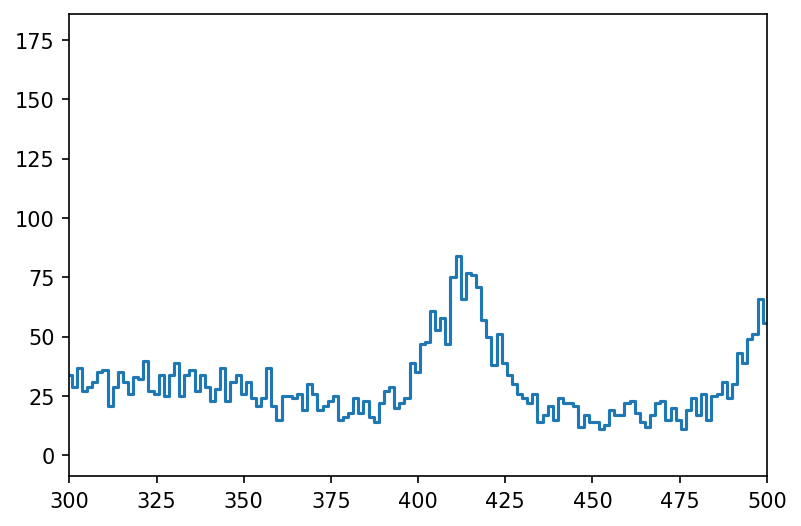

In [10]:
#Matplotlib figure details 

fig,ax=plt.subplots(1,1,figsize=(10,10))
fig.set_dpi(150)
fig.set_size_inches(6,4)
plt.step(x_cal,y_data)
plt.xlim(300,500)

In [11]:
# Looking at the 417 keV Gamma-Ray  

In [12]:
E_min = 350
E_max = 475

In [13]:
# Masking in the energy range of interest 
mask1 = x_cal > E_min
x_cal_m1 = x_cal[mask1]
y_data_m1 = y_data[mask1]
y_data_err_m1 = y_data_err[mask1]

mask2 = x_cal_m1 < E_max
x_cal_m2 = x_cal_m1[mask2]
y_data_m2 = y_data_m1[mask2]
y_data_m2_err = y_data_err_m1[mask2]


In [14]:
# Fitting Parameters
norm_min=np.min(y_data_m2)*100
norm_max=np.max(y_data_m2)*100
mean_min= 417-20
mean_max= 417 +20 
sigma_min=0
sigma_max=20
slope_min = -10
intercept_min = -1000
slope_max = 10
intercept_max = 1000

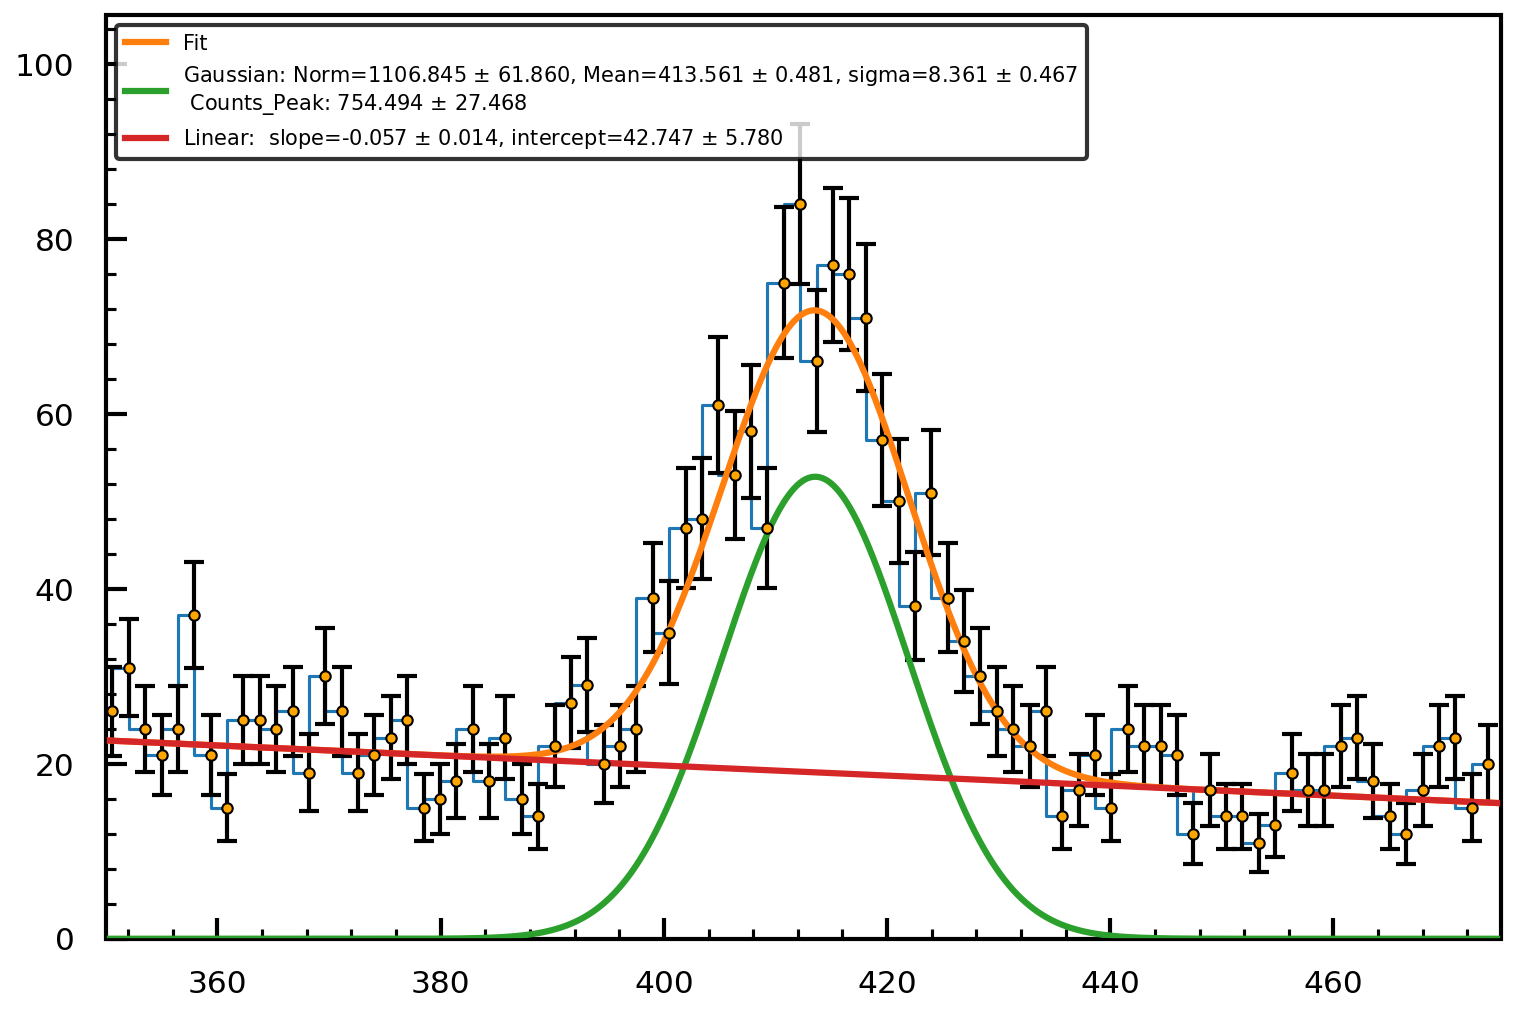

In [15]:
#Matplotlib figure details 
fig,ax=plt.subplots(1,1,figsize=(20,20))
fig.set_dpi(150)
fig.set_size_inches(12,8)

#Axis ticks 
ax.tick_params(which='major', direction='in', width=2, length=10, color='k', pad=15)
ax.tick_params(which='minor', direction='in', width=1.5, length=5, color='k', pad=15)
ax.xaxis.set_minor_locator(mtick.AutoMinorLocator(5))
ax.yaxis.set_minor_locator(mtick.AutoMinorLocator(5))
ax.tick_params(labelsize=15)
ax.patch.set_edgecolor('k')
ax.patch.set_linewidth(2) 


popt, pcov = curve_fit(fitFunc_1,x_cal_m2,y_data_m2,bounds=([norm_min,mean_min,sigma_min,slope_min,intercept_min],[norm_max,mean_max,sigma_max,slope_max,intercept_max]),sigma=y_data_m2_err) 


x = np.linspace(E_min, E_max, 2000)
y = fitFunc_1(x, *popt)
perr =  np.sqrt(np.diag(pcov))
y1 = gaussian1(x,popt[0],popt[1],popt[2])
#y2 = quadratic(x,popt[3],popt[4],popt[5])
y2 = linear(x,popt[3],popt[4])


Counts_Peak = popt[0]/(binwidth)


plt.step(x_cal_m2,y_data_m2)
ax.errorbar(x_cal_m2,y_data_m2,y_data_m2_err,fmt='o',color="orange",ms=5,ecolor='k',solid_capstyle='projecting', capsize=5,capthick=2,elinewidth=2,markeredgecolor="k")
plt.plot(x,y,label="Fit",linewidth=3)
plt.plot(x,y1,label="Gaussian: Norm=%5.3f $\\pm$ %5.3f, Mean=%5.3f $\\pm$ %5.3f, sigma=%5.3f $\\pm$ %5.3f\n Counts_Peak: %5.3f $\\pm$ %5.3f "%(popt[0],perr[0],popt[1],perr[1],popt[2],perr[2],Counts_Peak,np.sqrt(Counts_Peak)),linewidth=3)
plt.plot(x,y2,label="Linear:  slope=%5.3f $\\pm$ %5.3f, intercept=%5.3f $\\pm$ %5.3f " %(popt[3],perr[3],popt[4],perr[4]),linewidth=3)
plt.xlim(E_min,E_max)
plt.ylim(0,(2*popt[0])/(popt[2]*np.sqrt(2*np.pi)))

#Legend Properties 
legend_properties = {'size':10}
leg =plt.legend(fontsize=10,loc=2)
leg.get_frame().set_edgecolor('k')
leg.get_frame().set_linewidth(2.0)

plt.show()




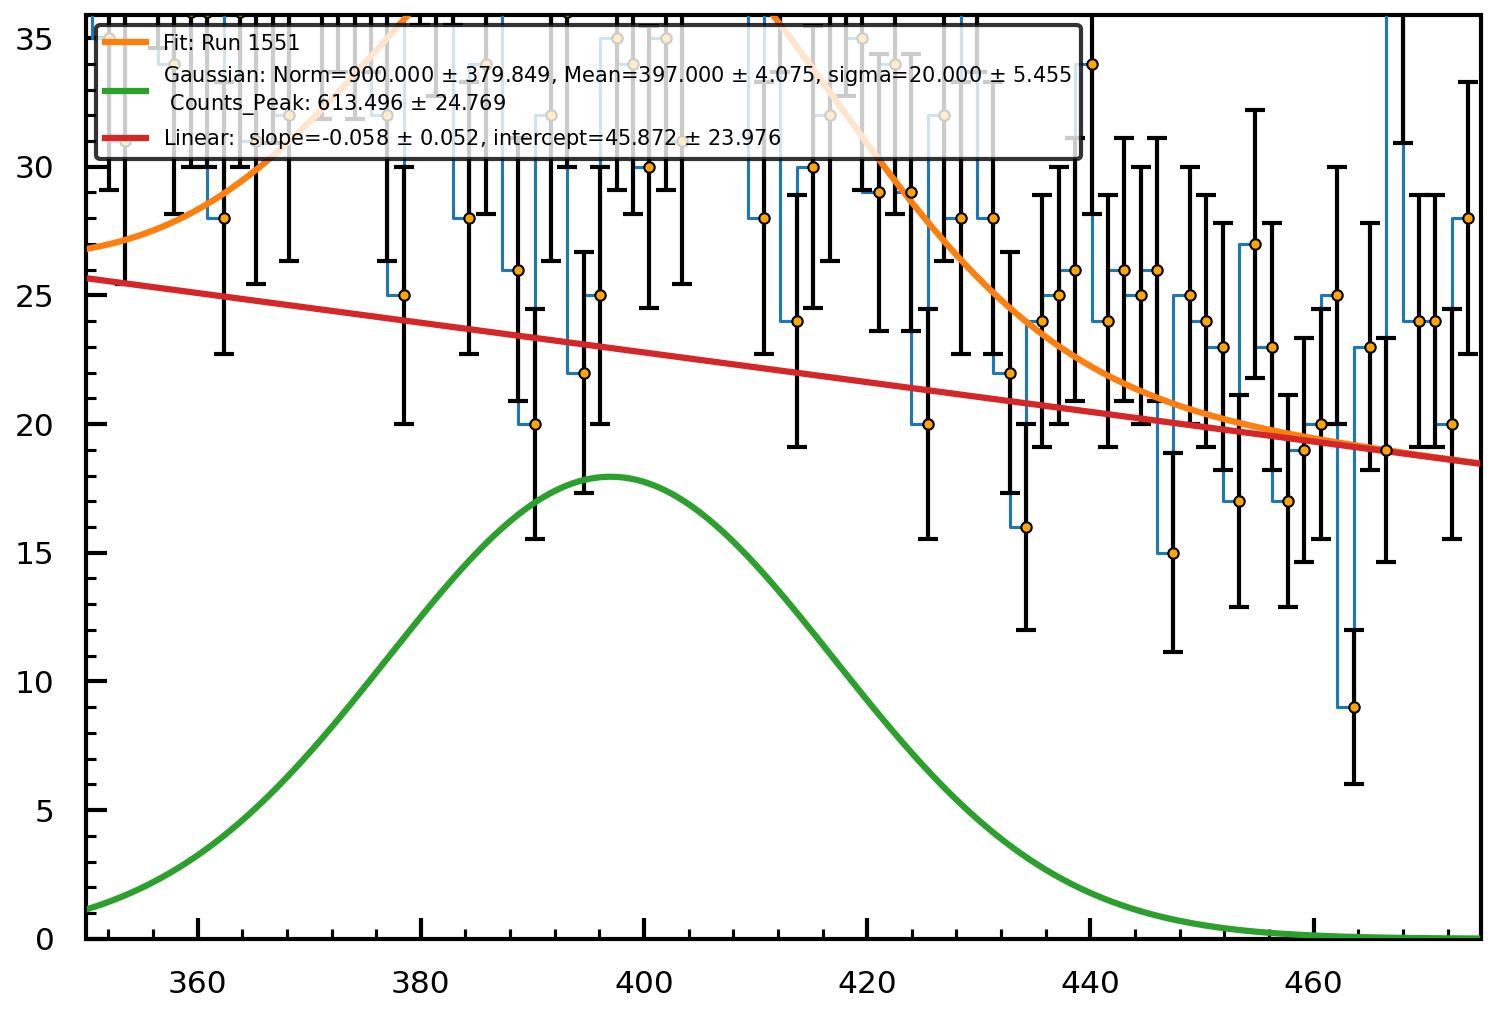

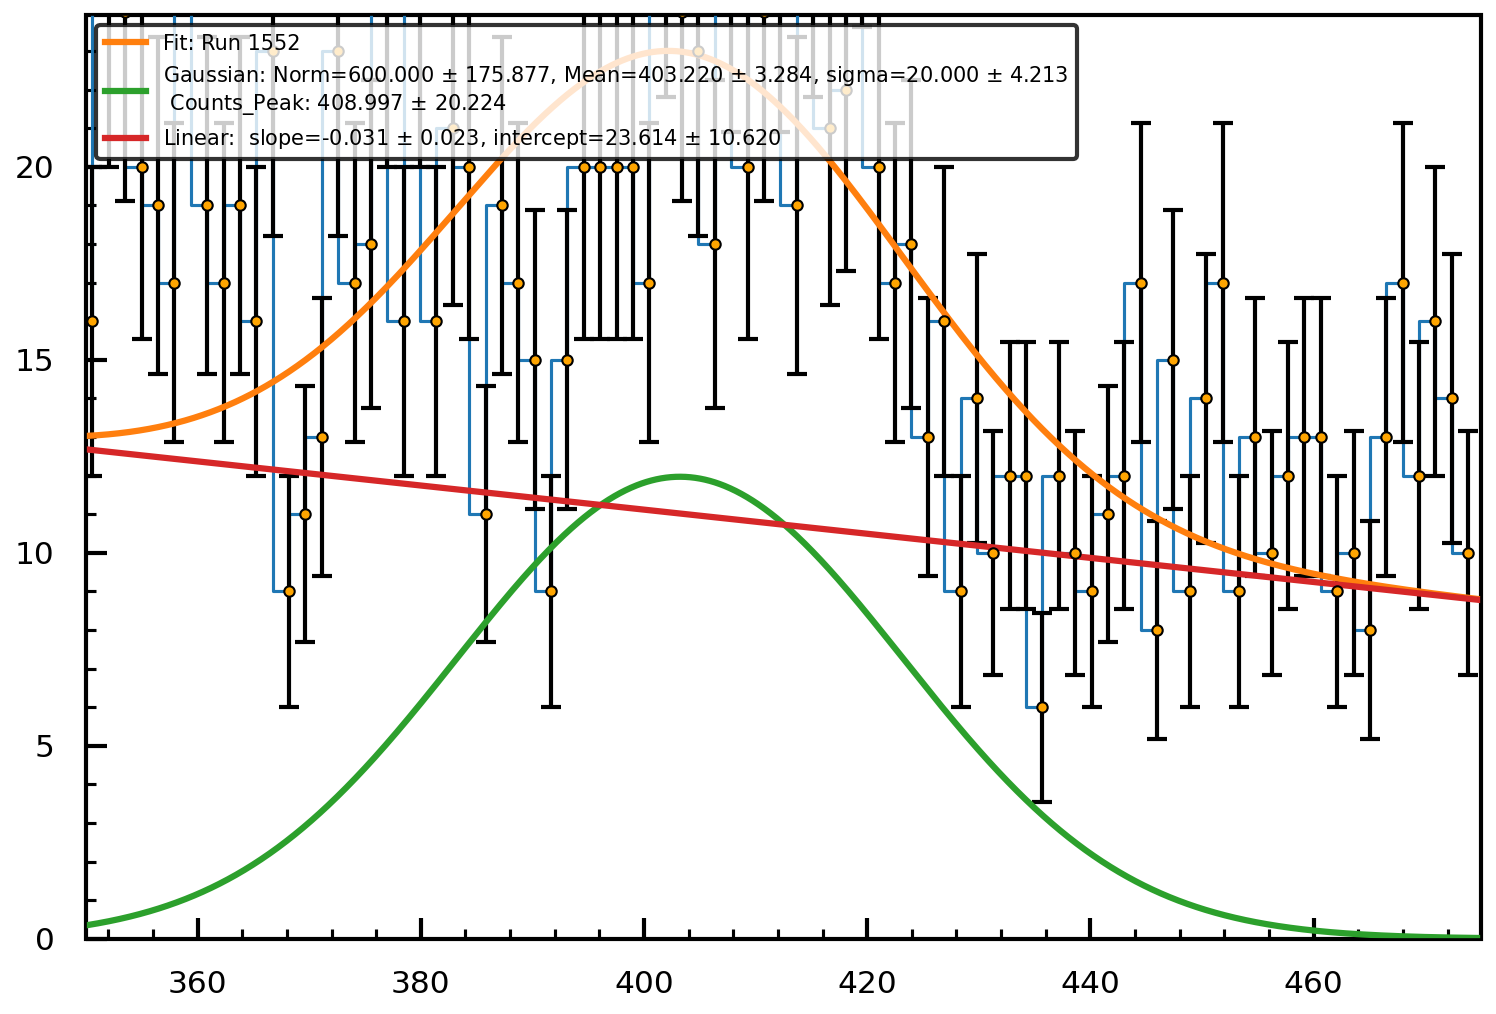

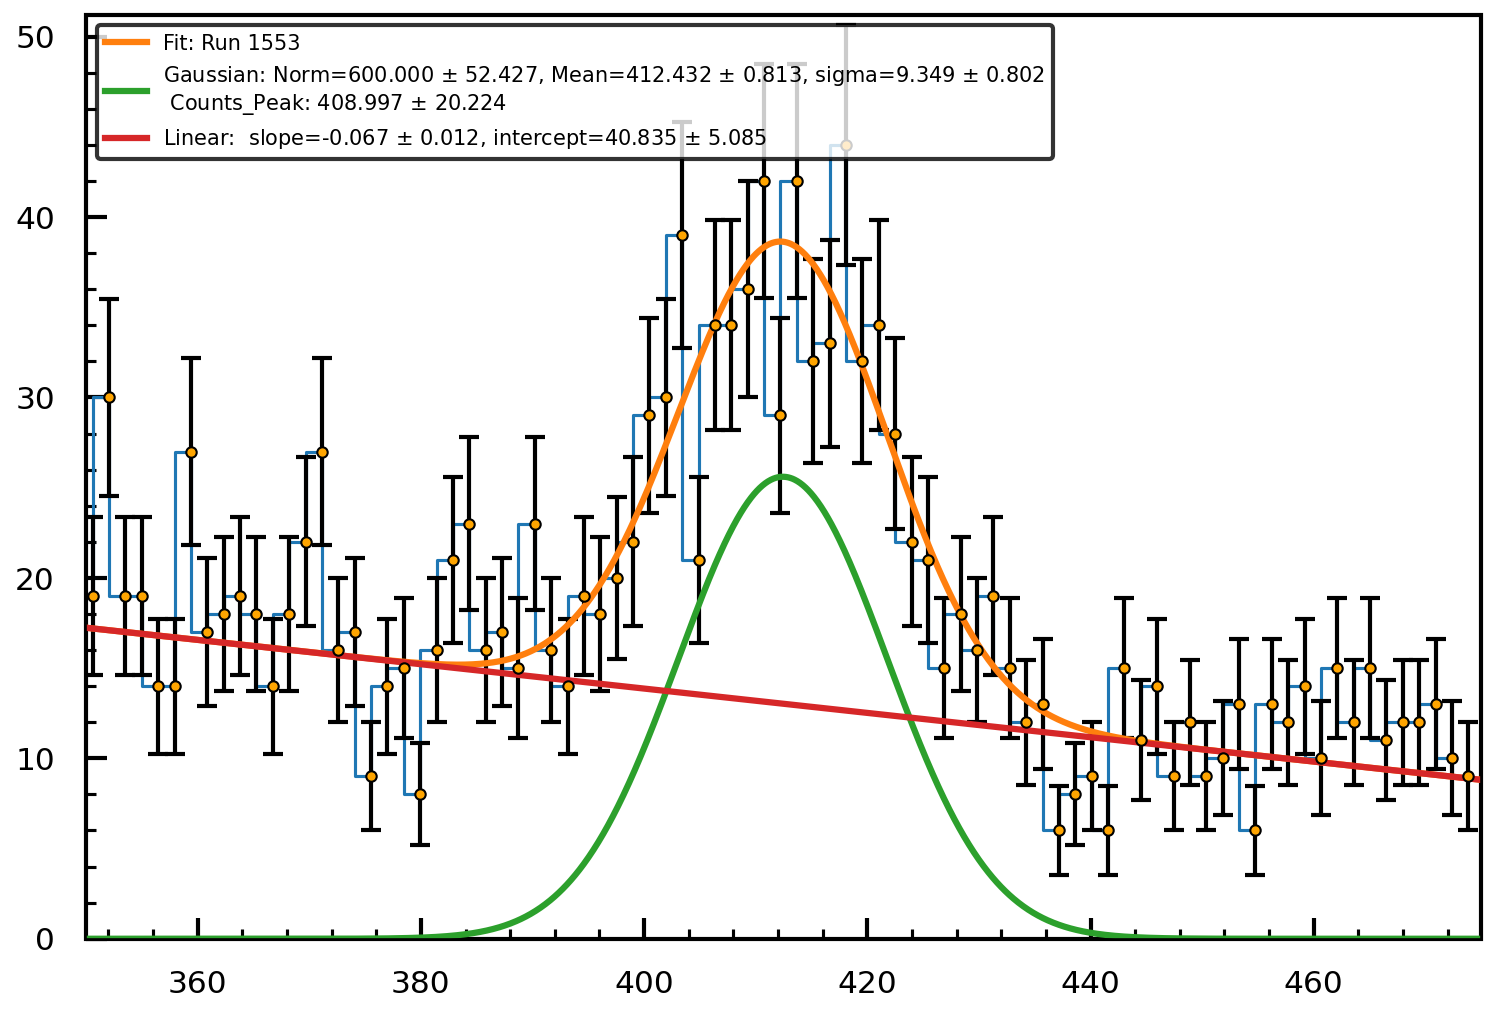

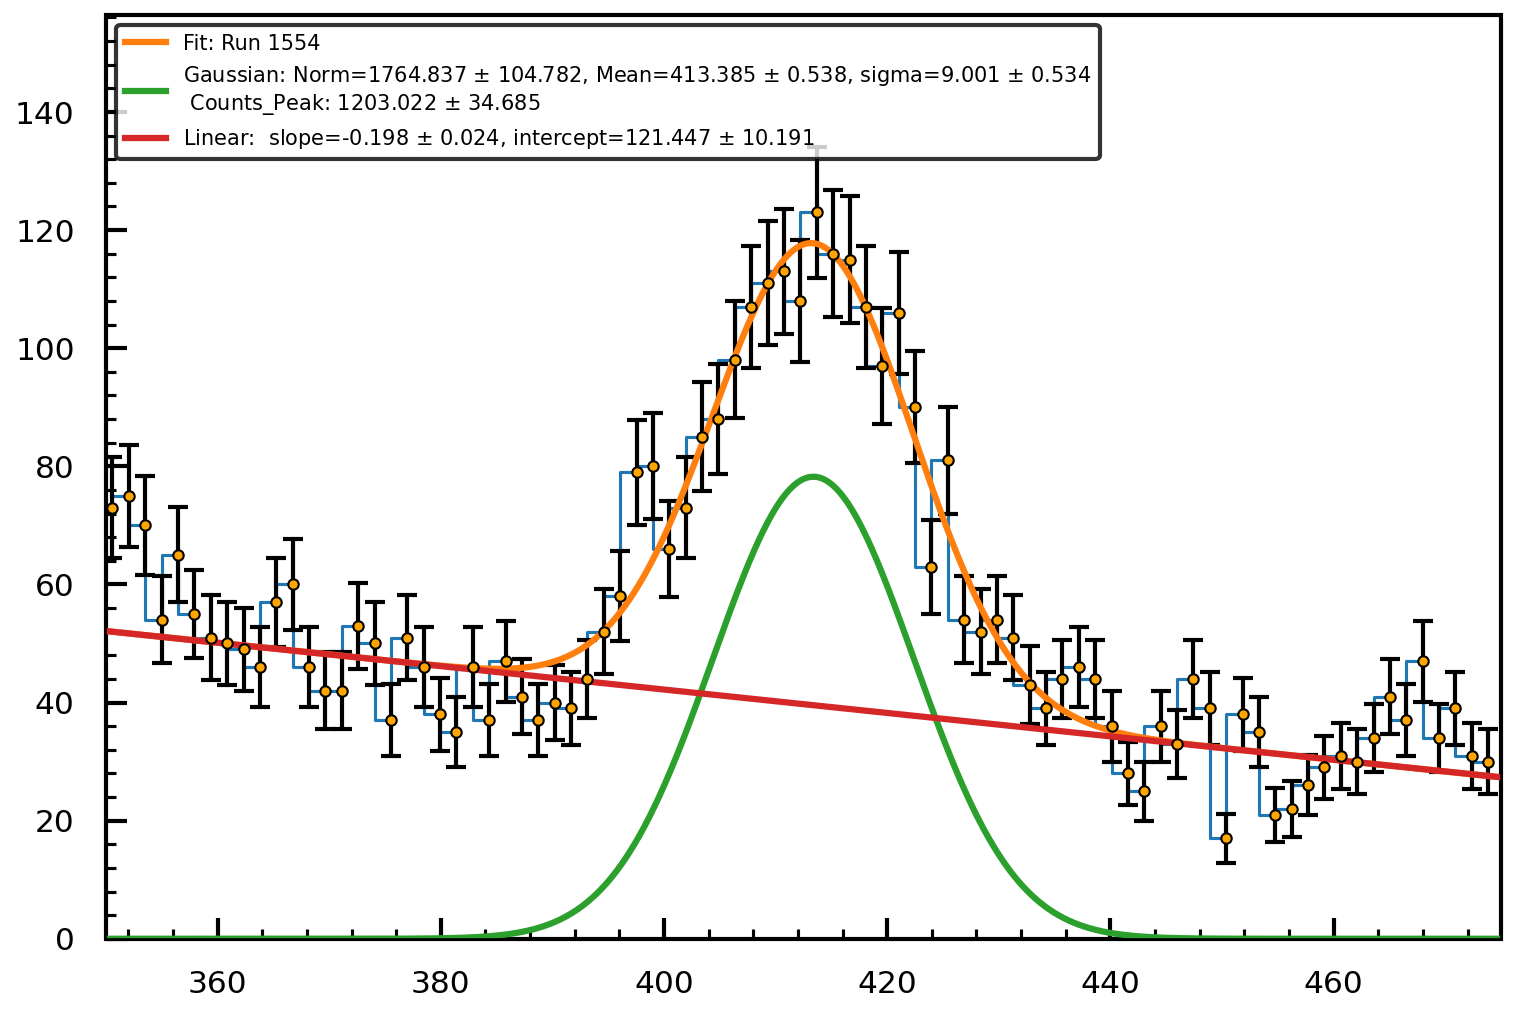

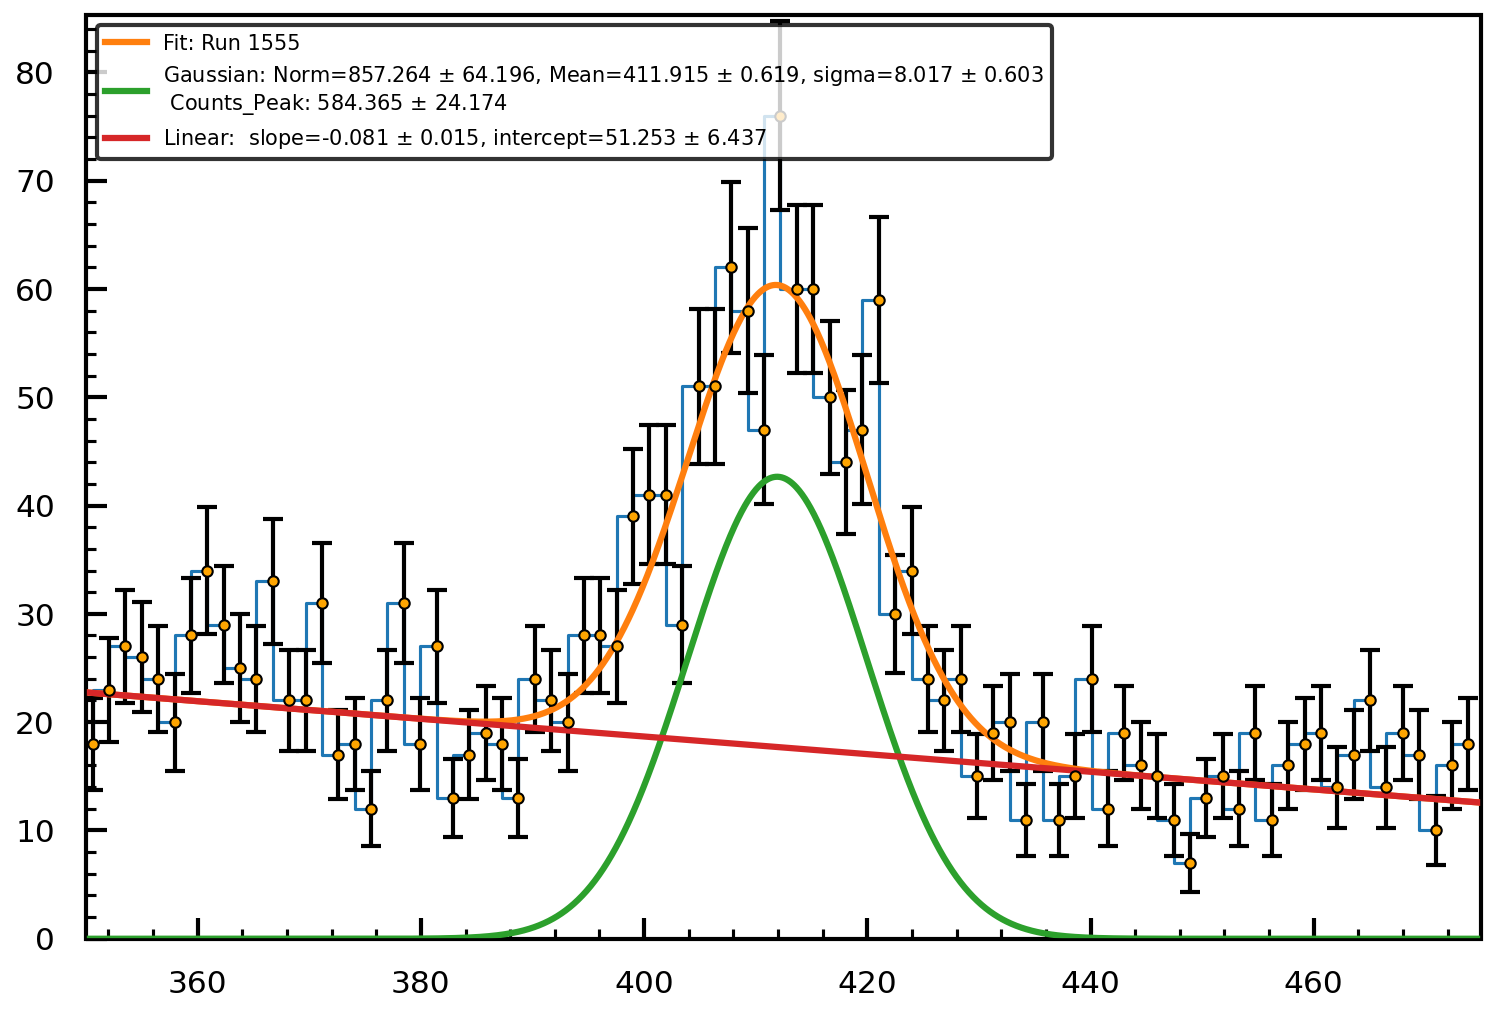

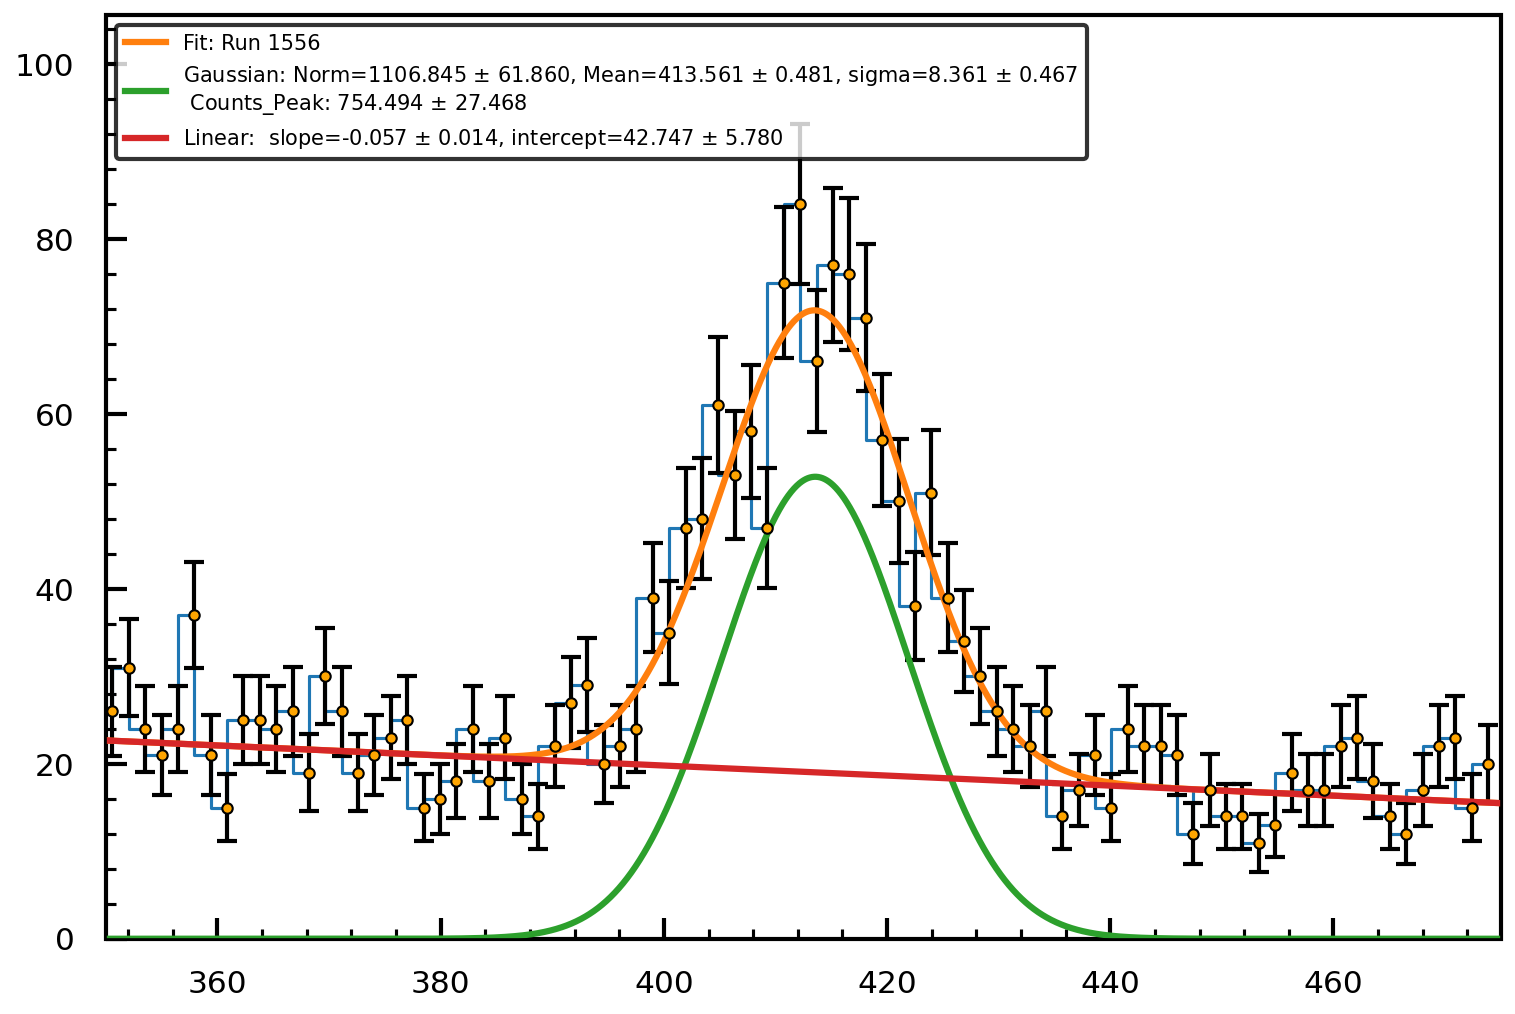

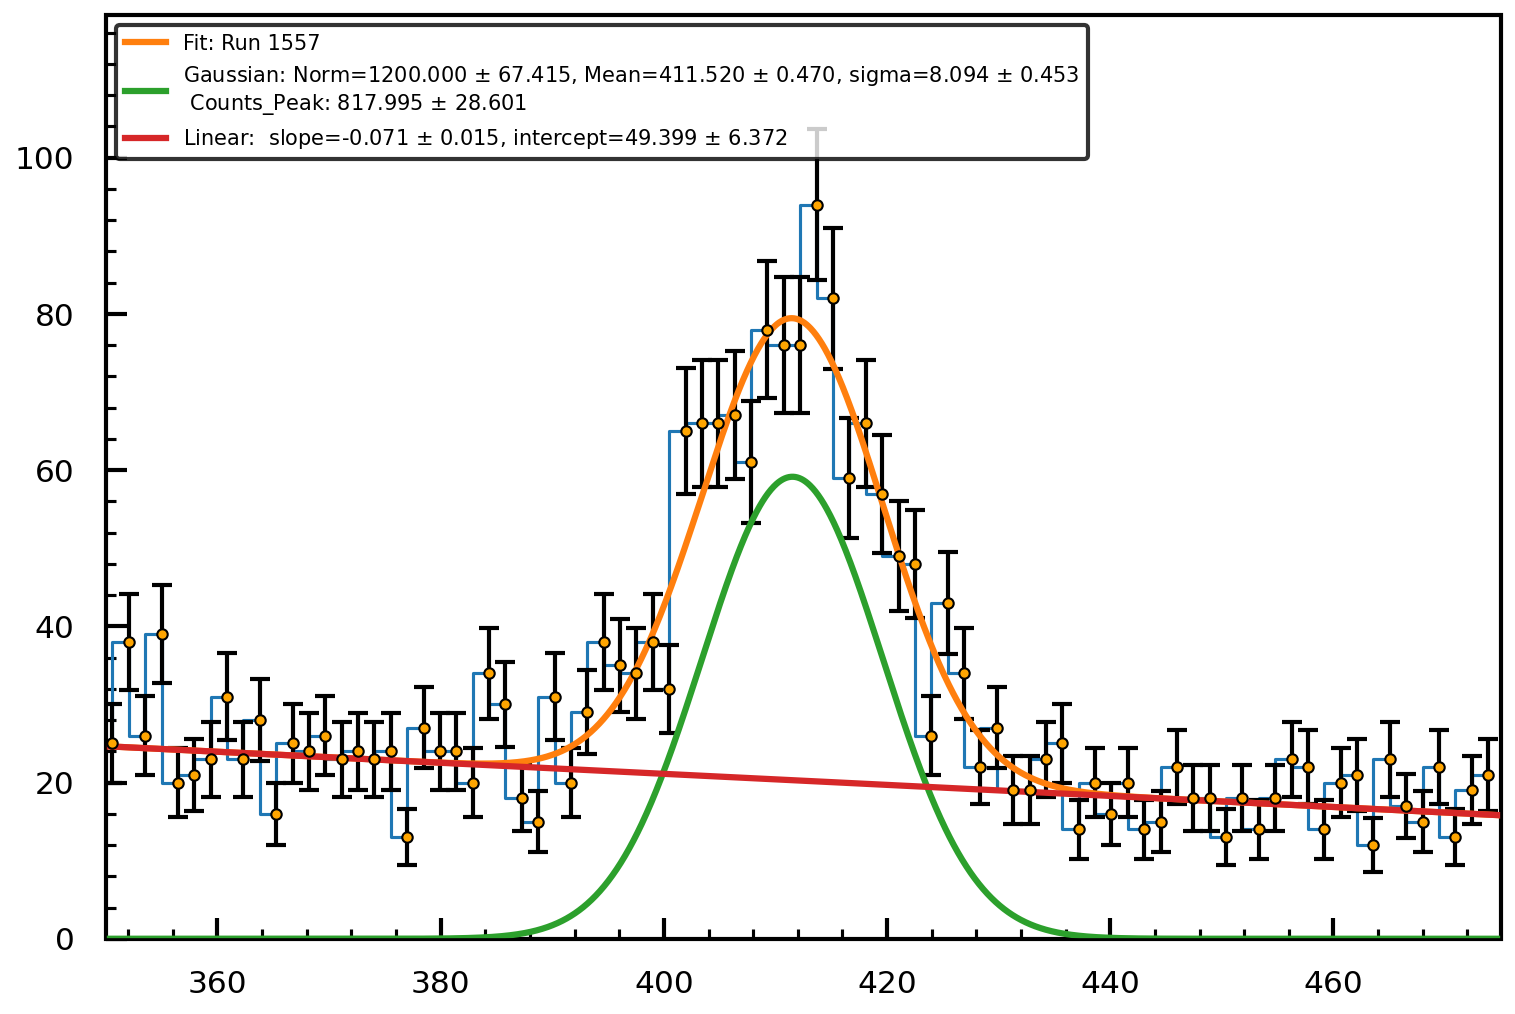

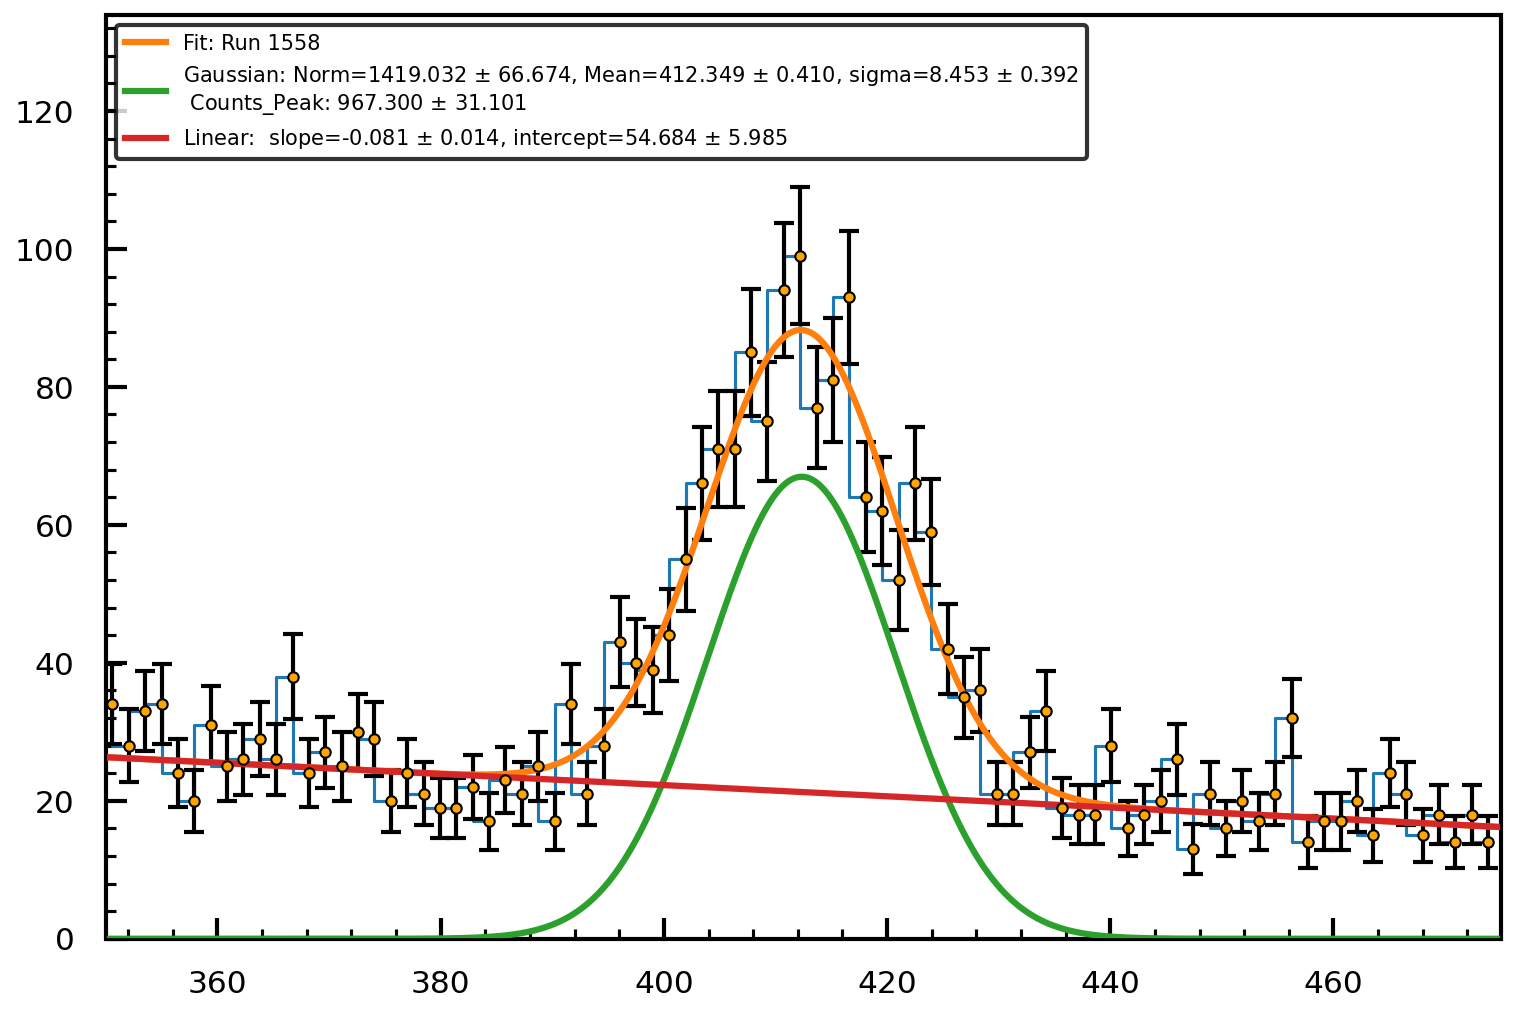

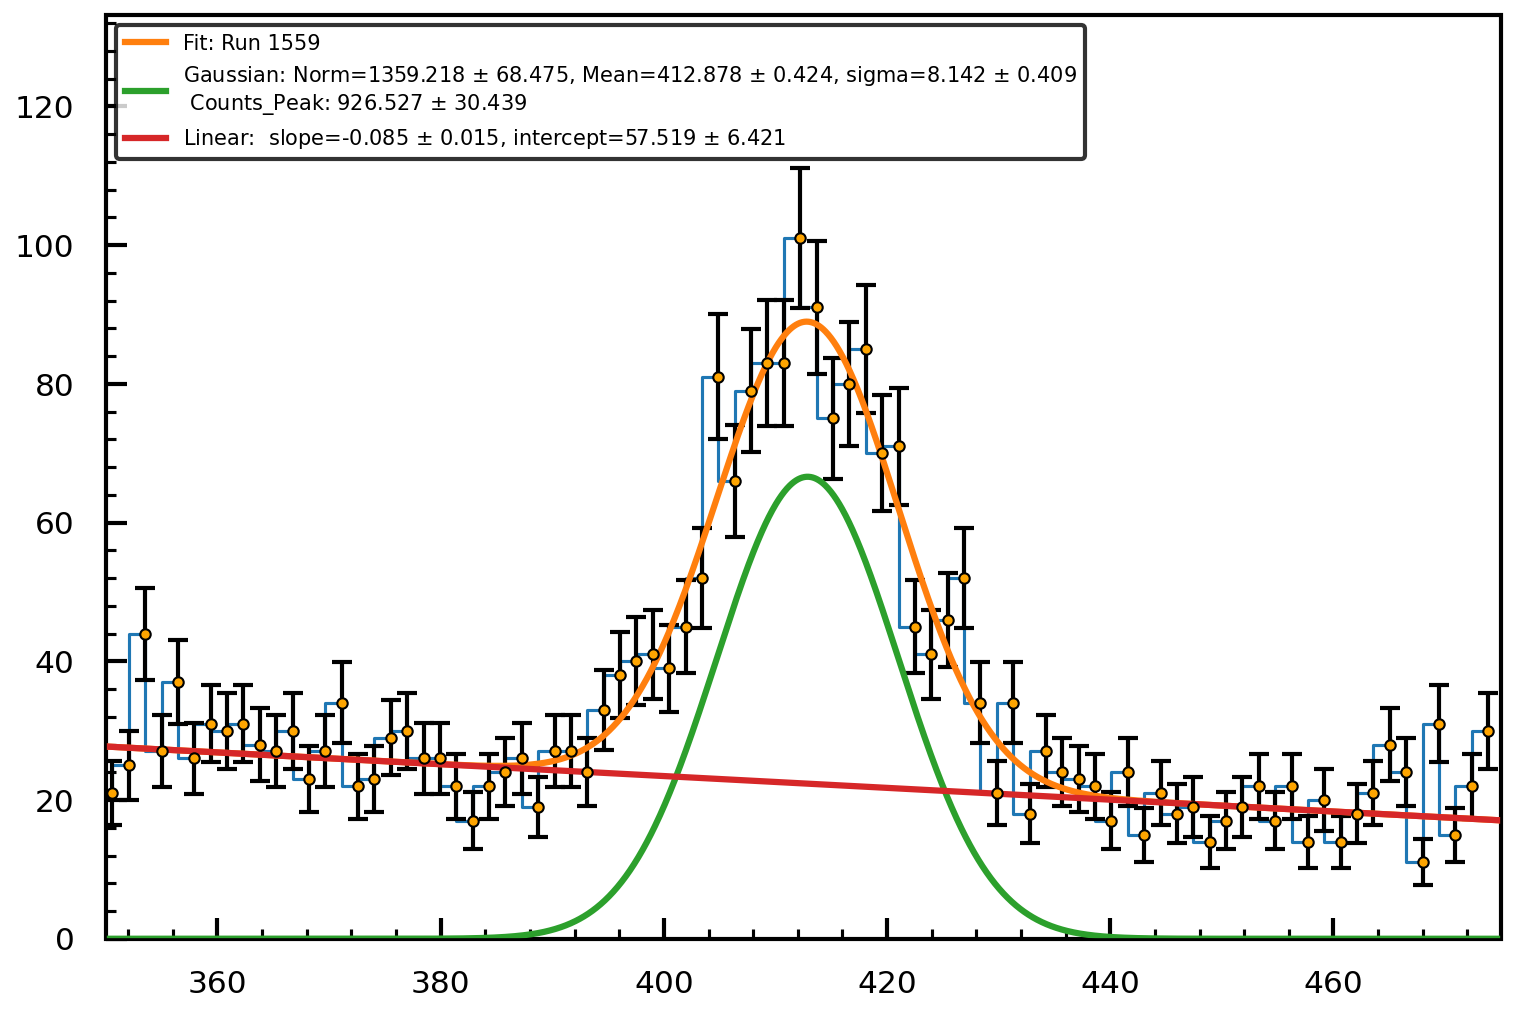

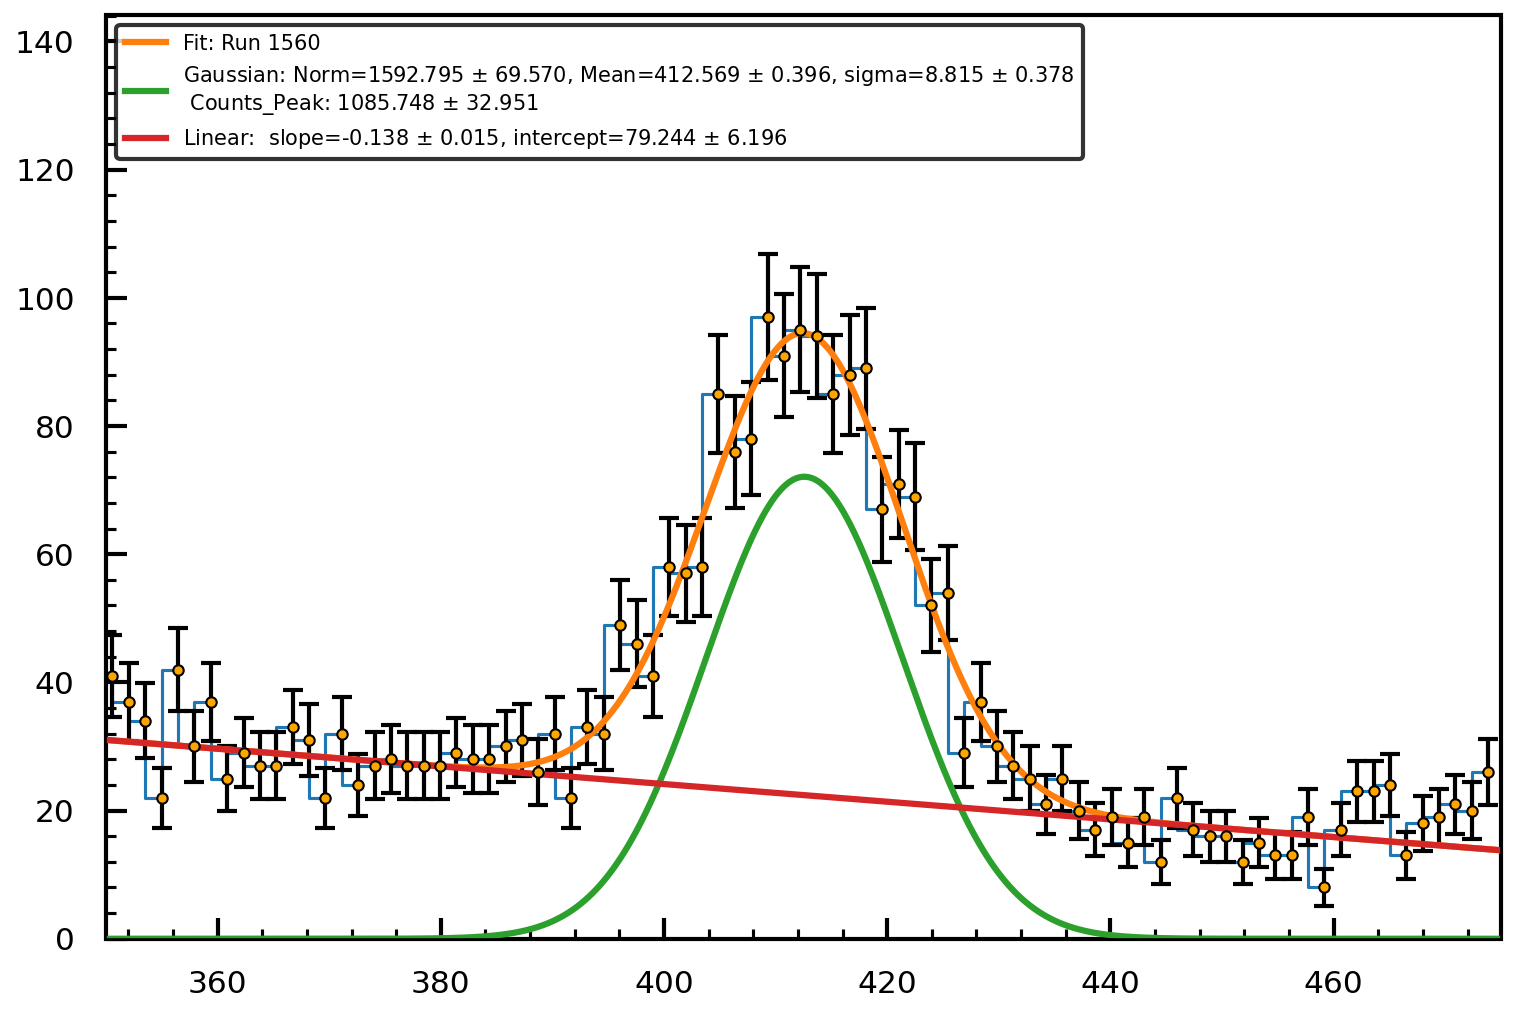

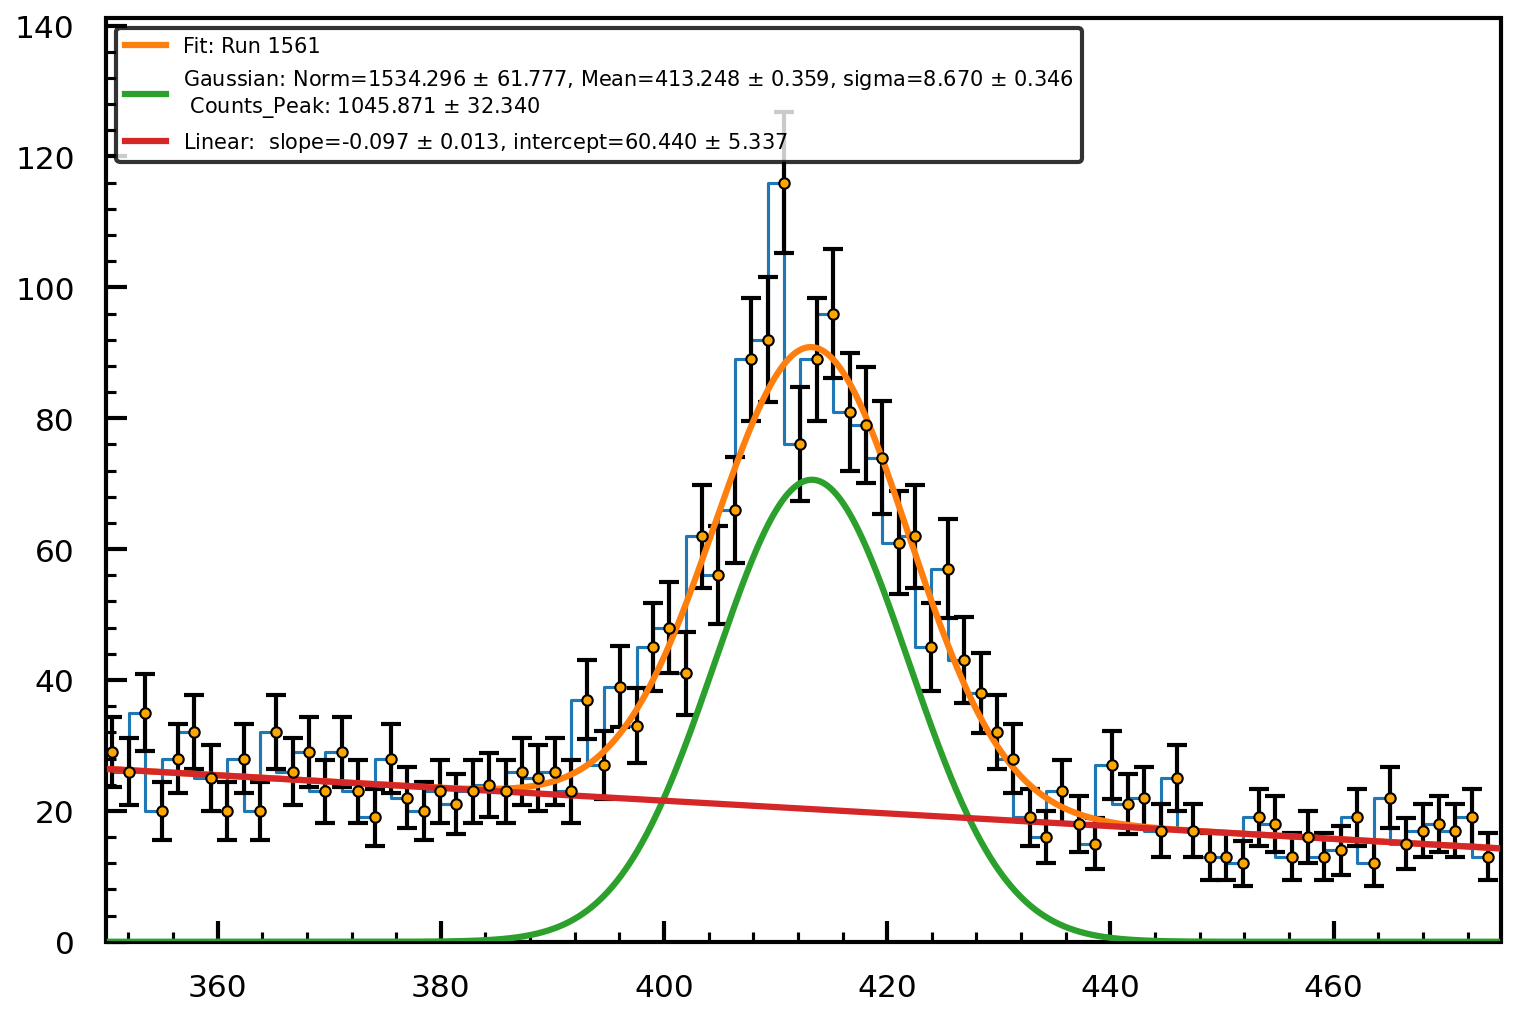

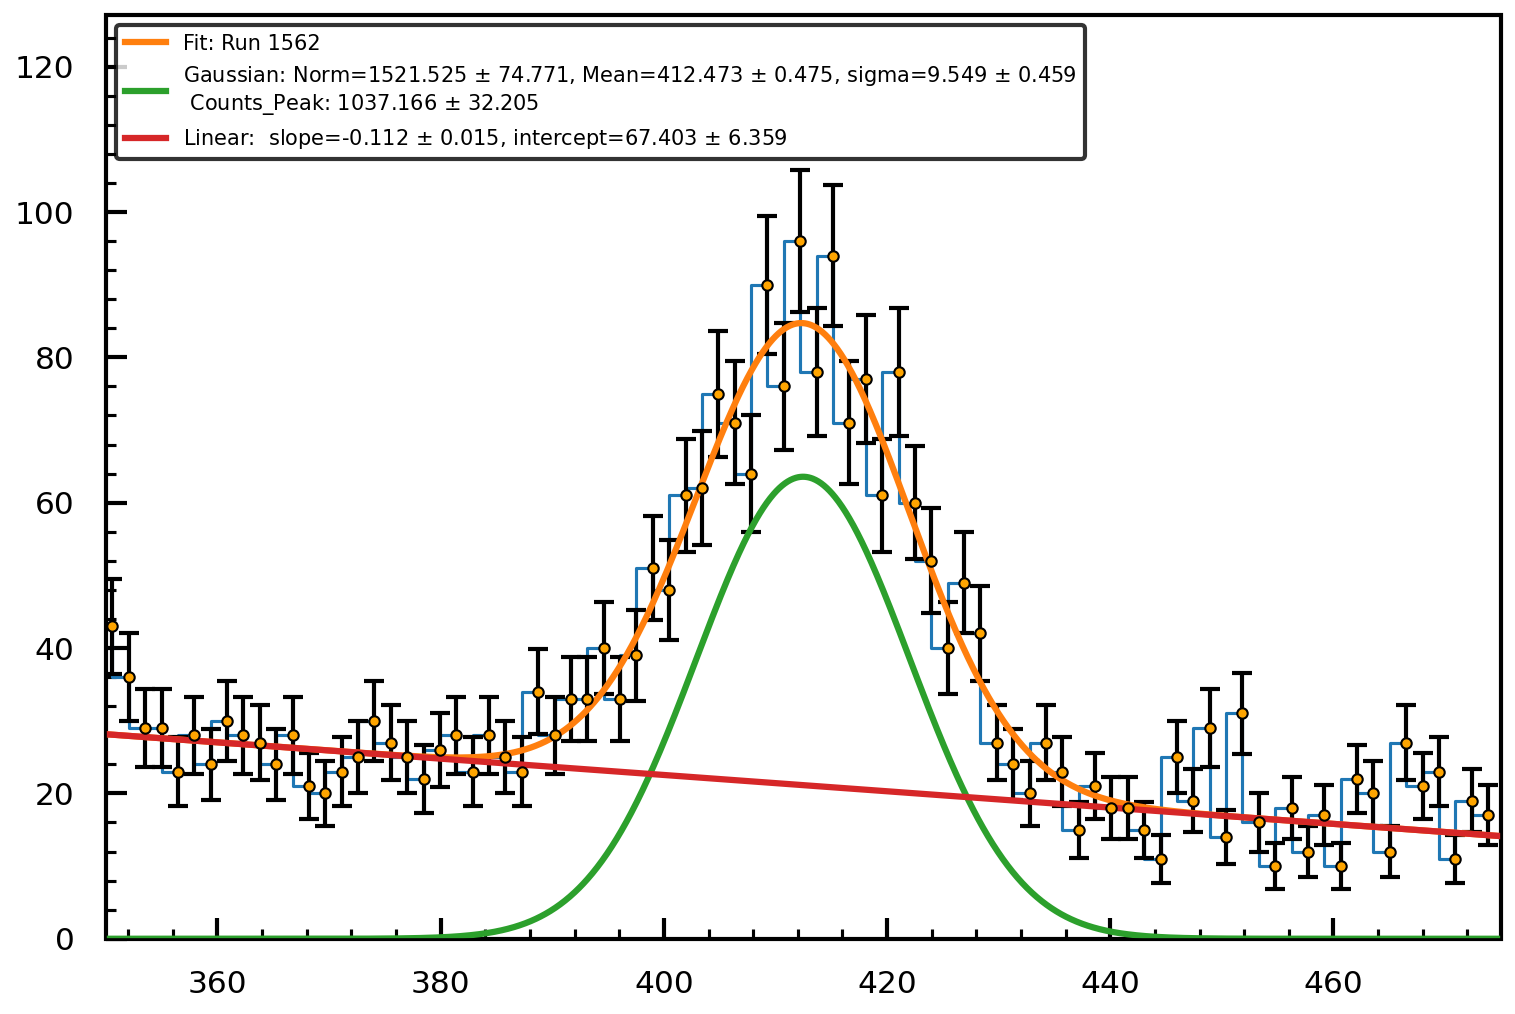

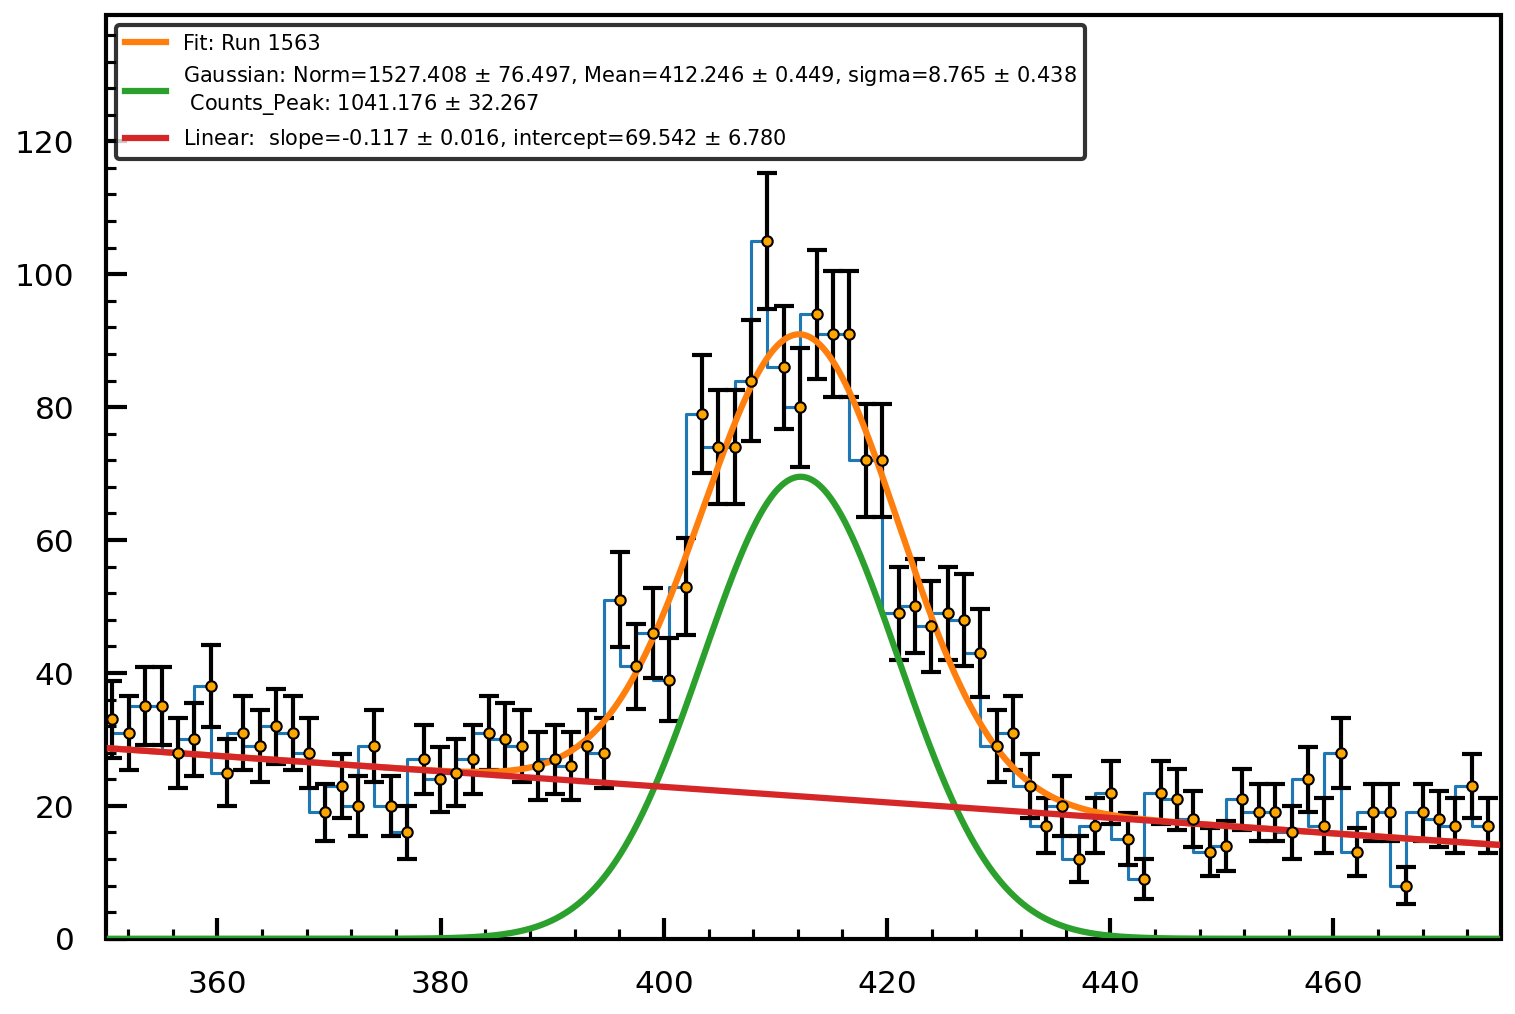

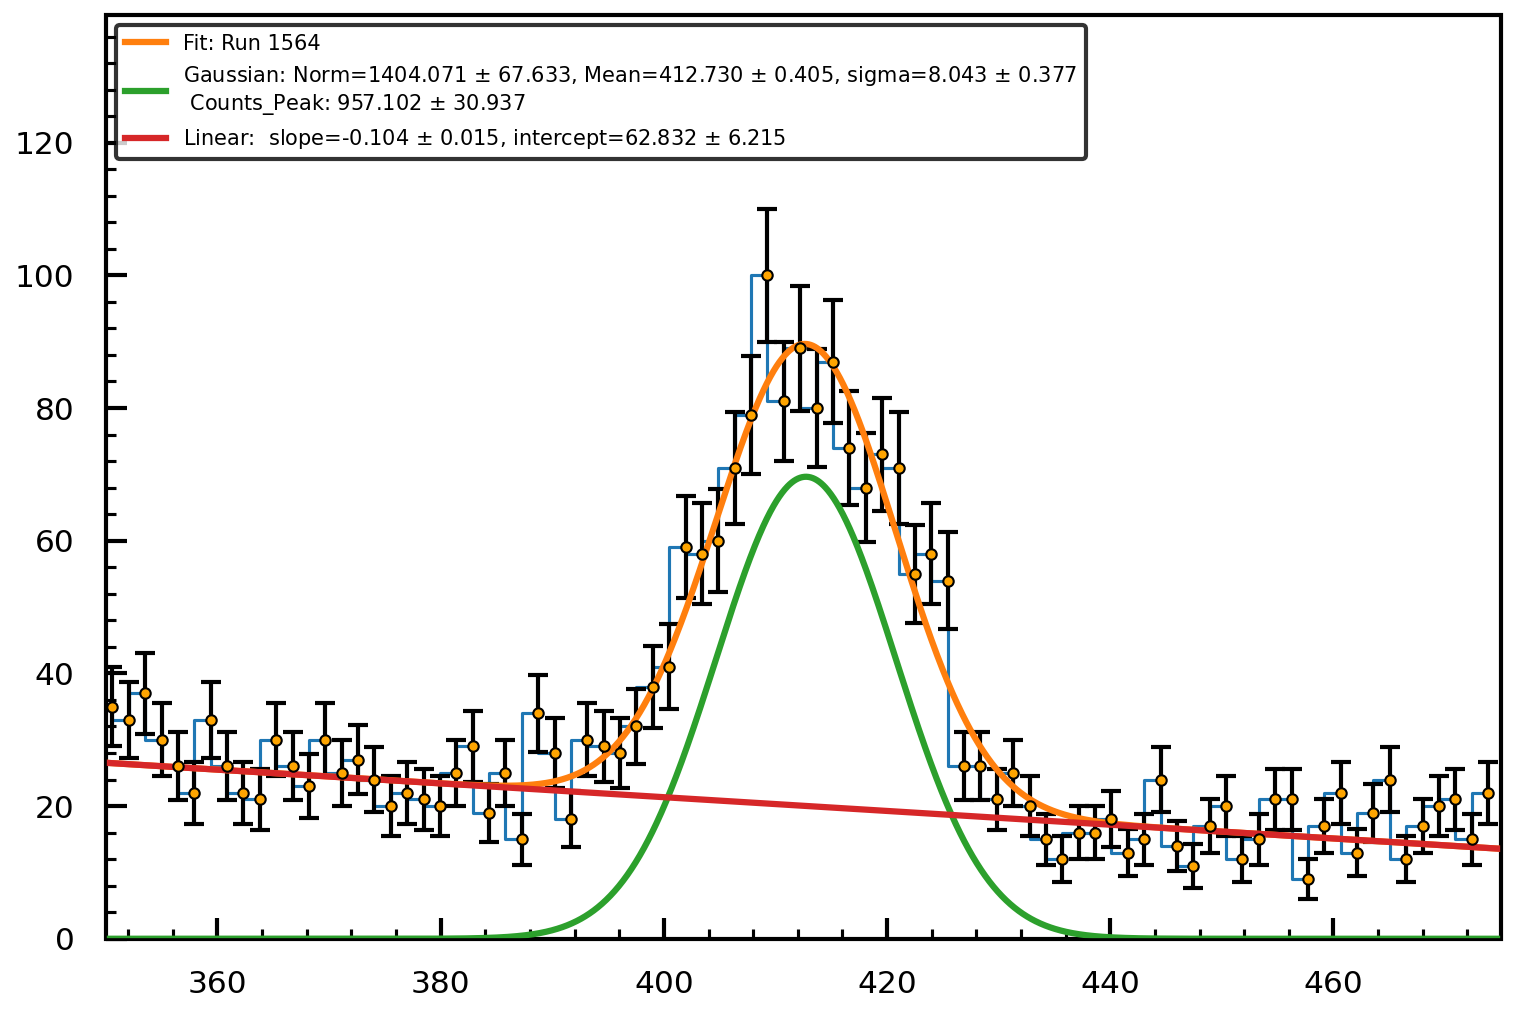

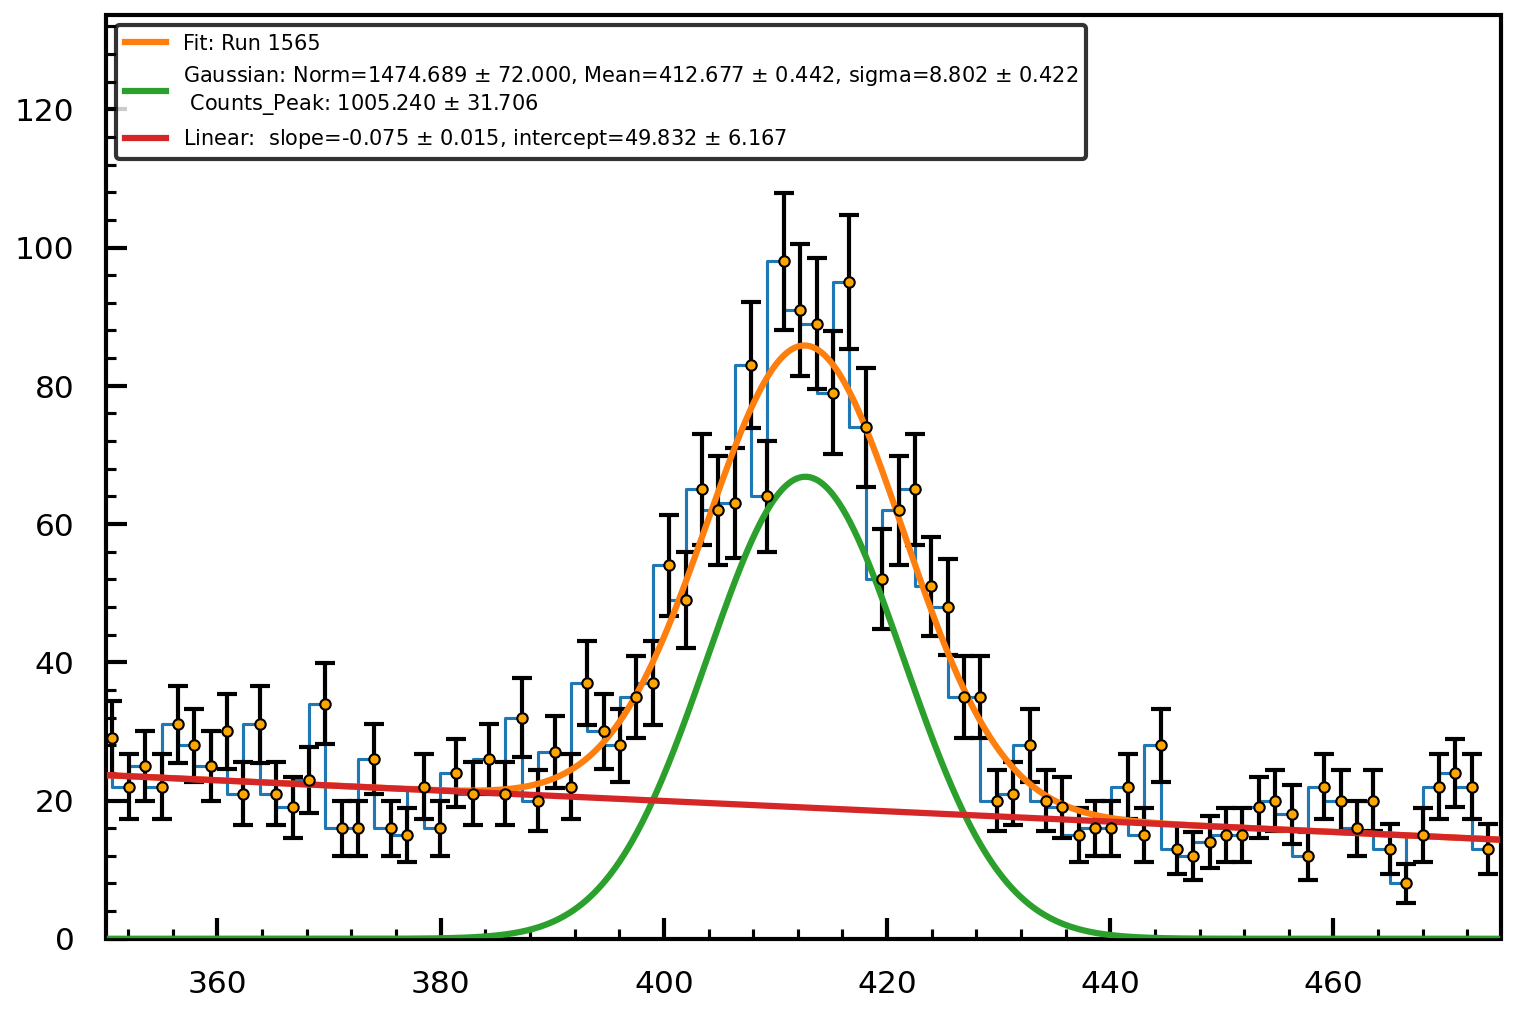

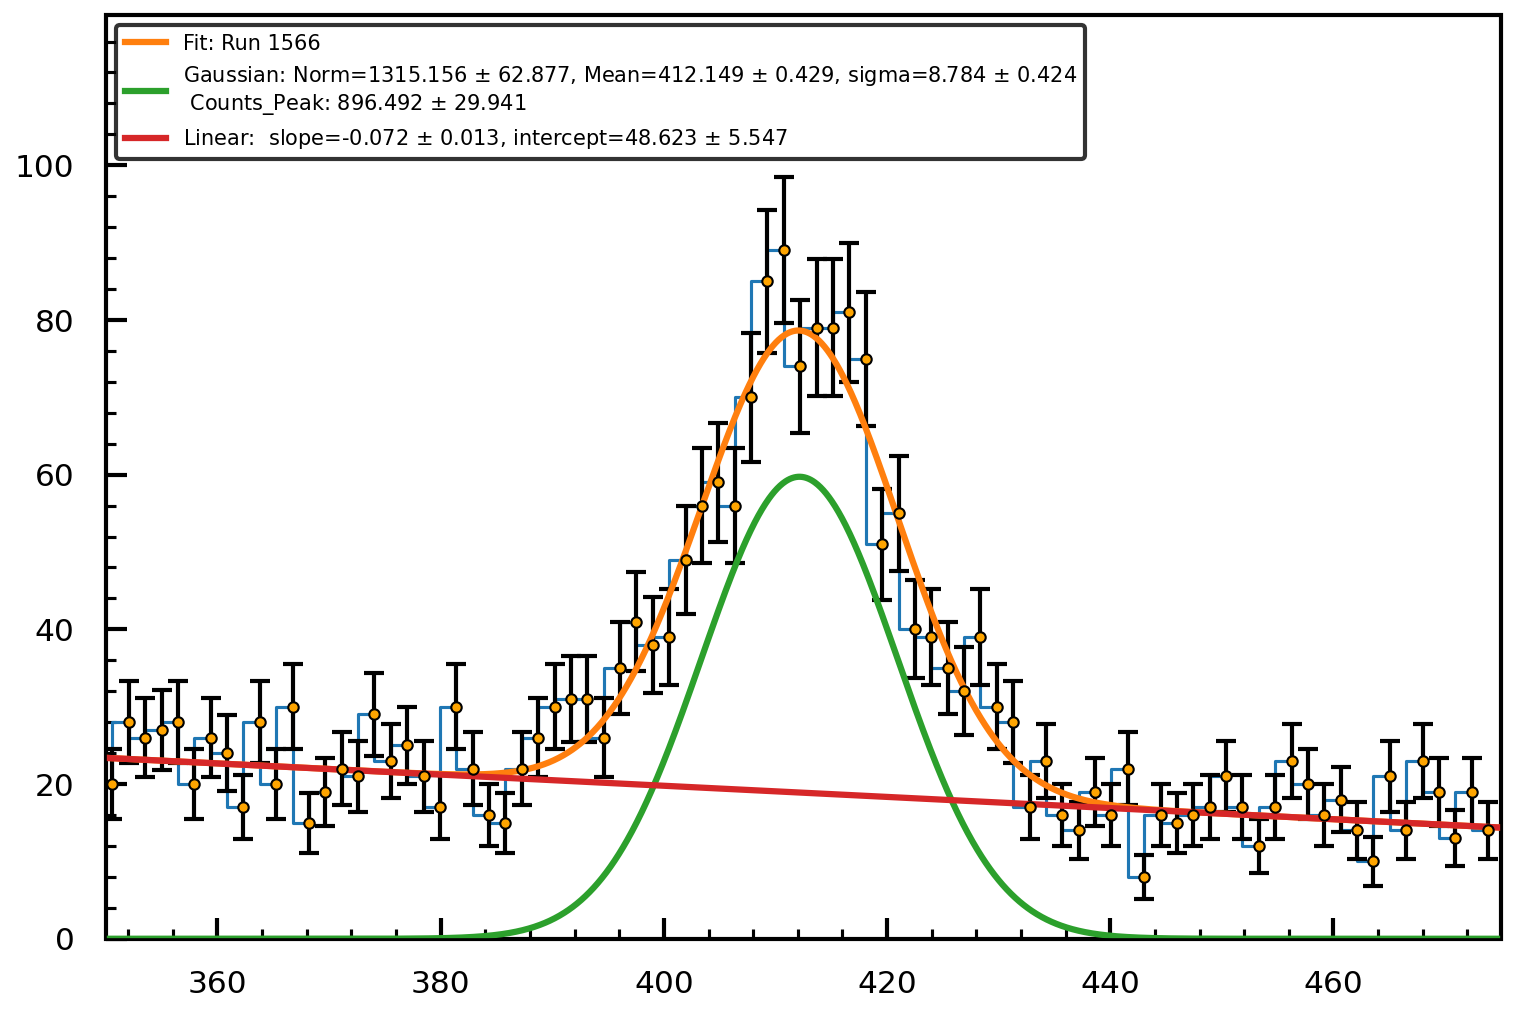

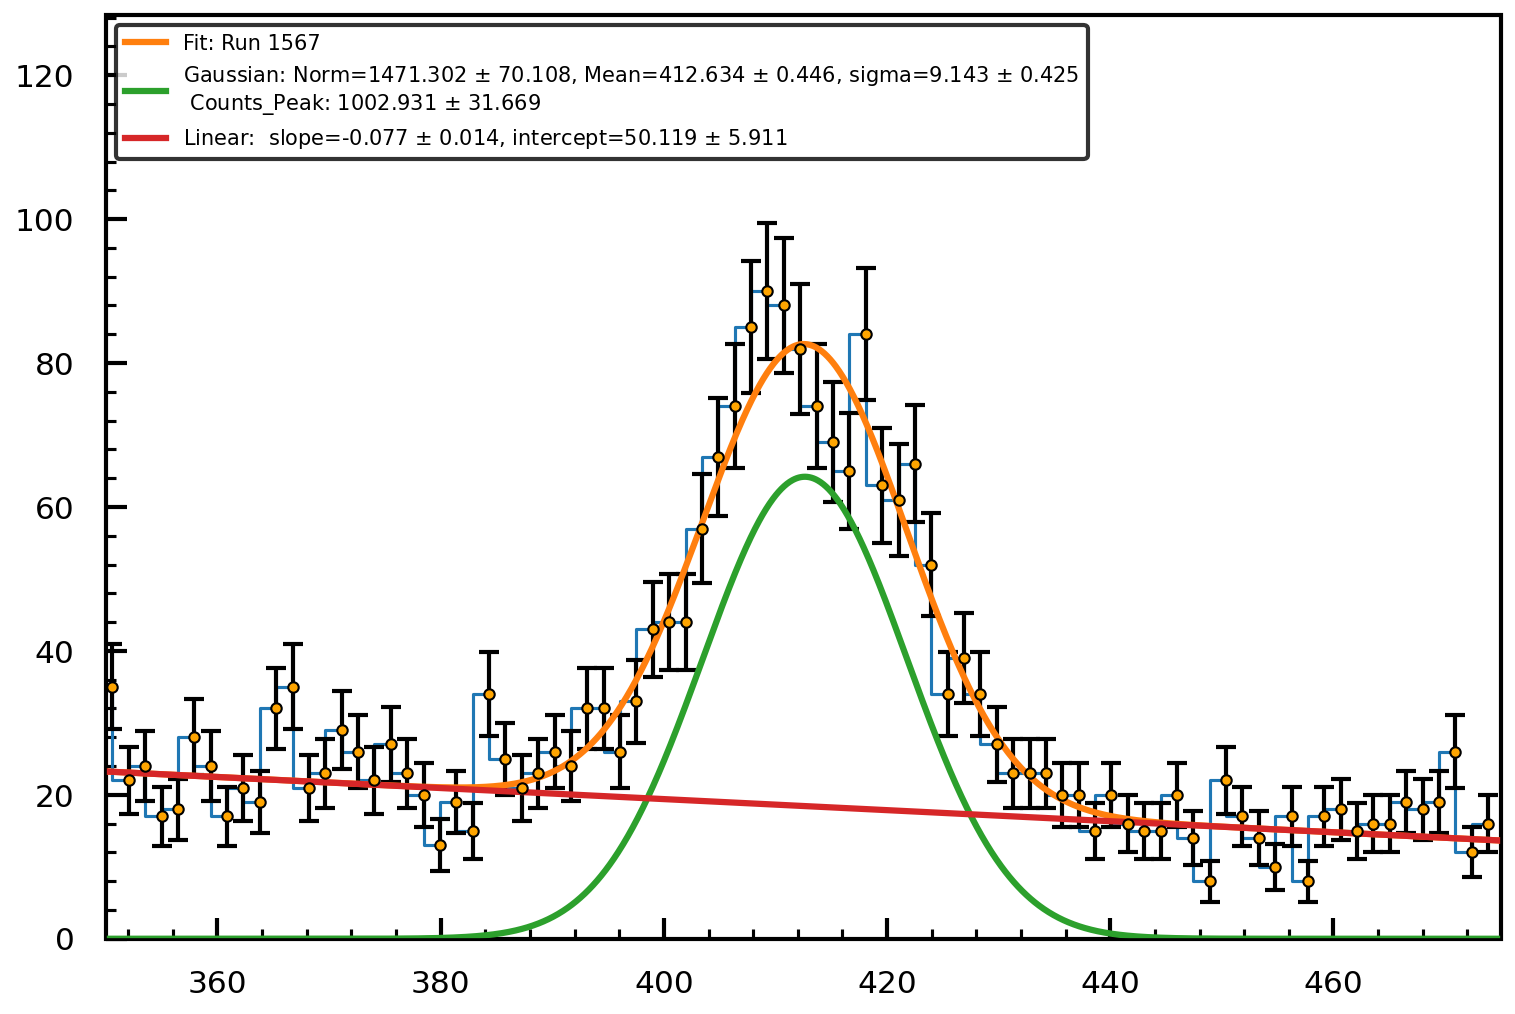

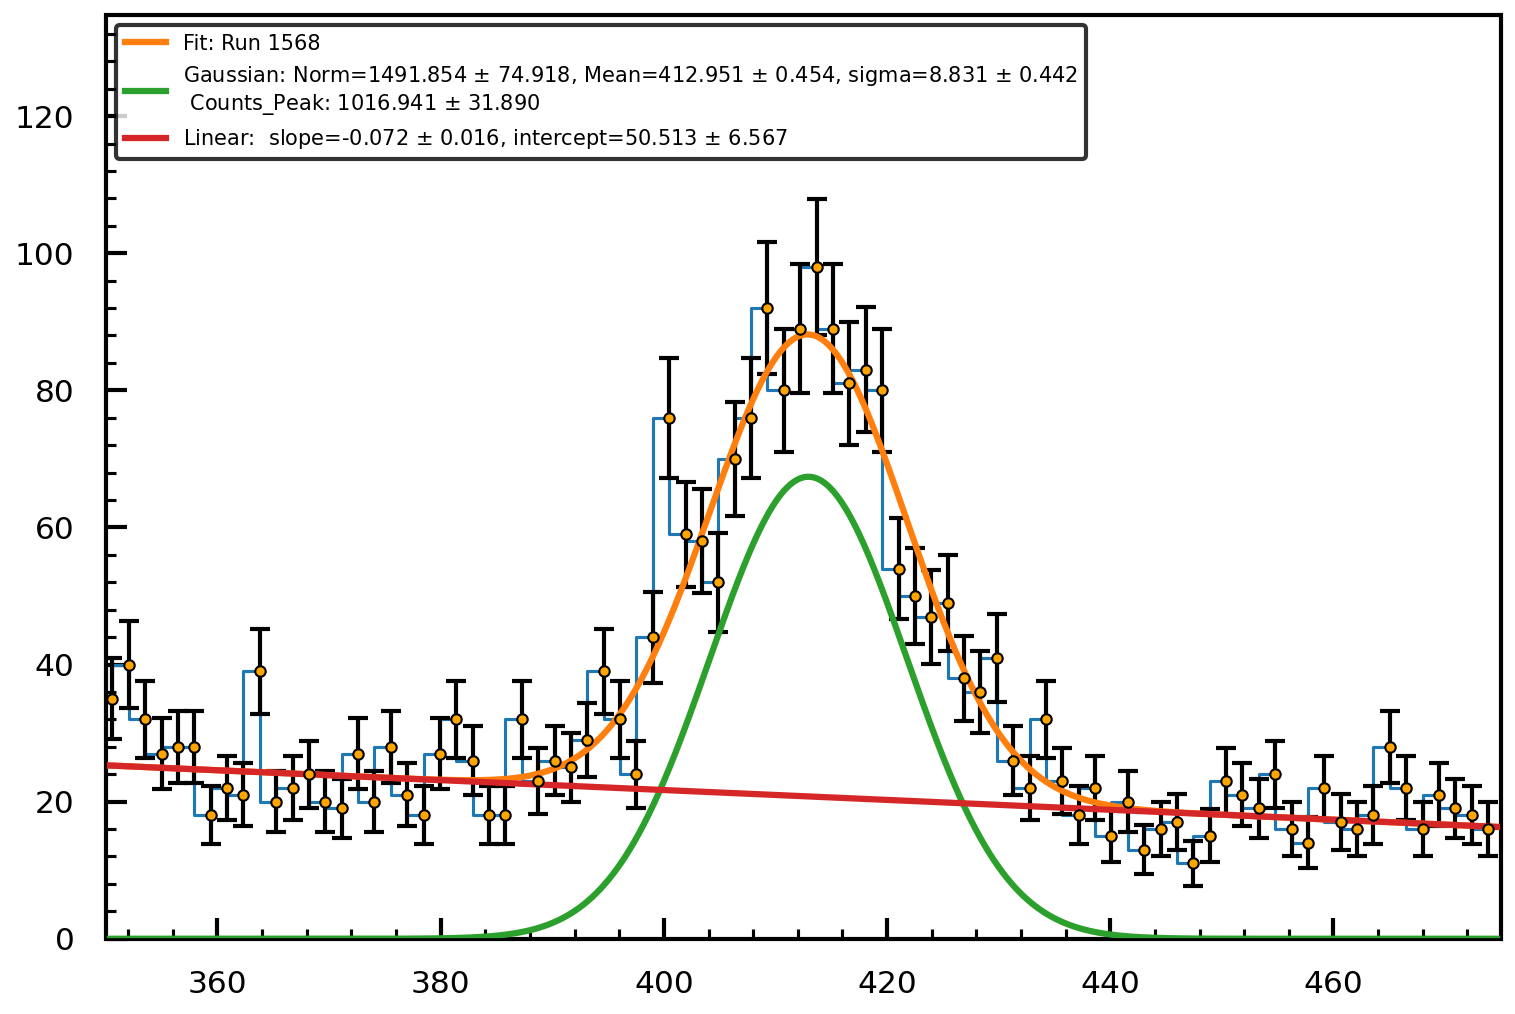

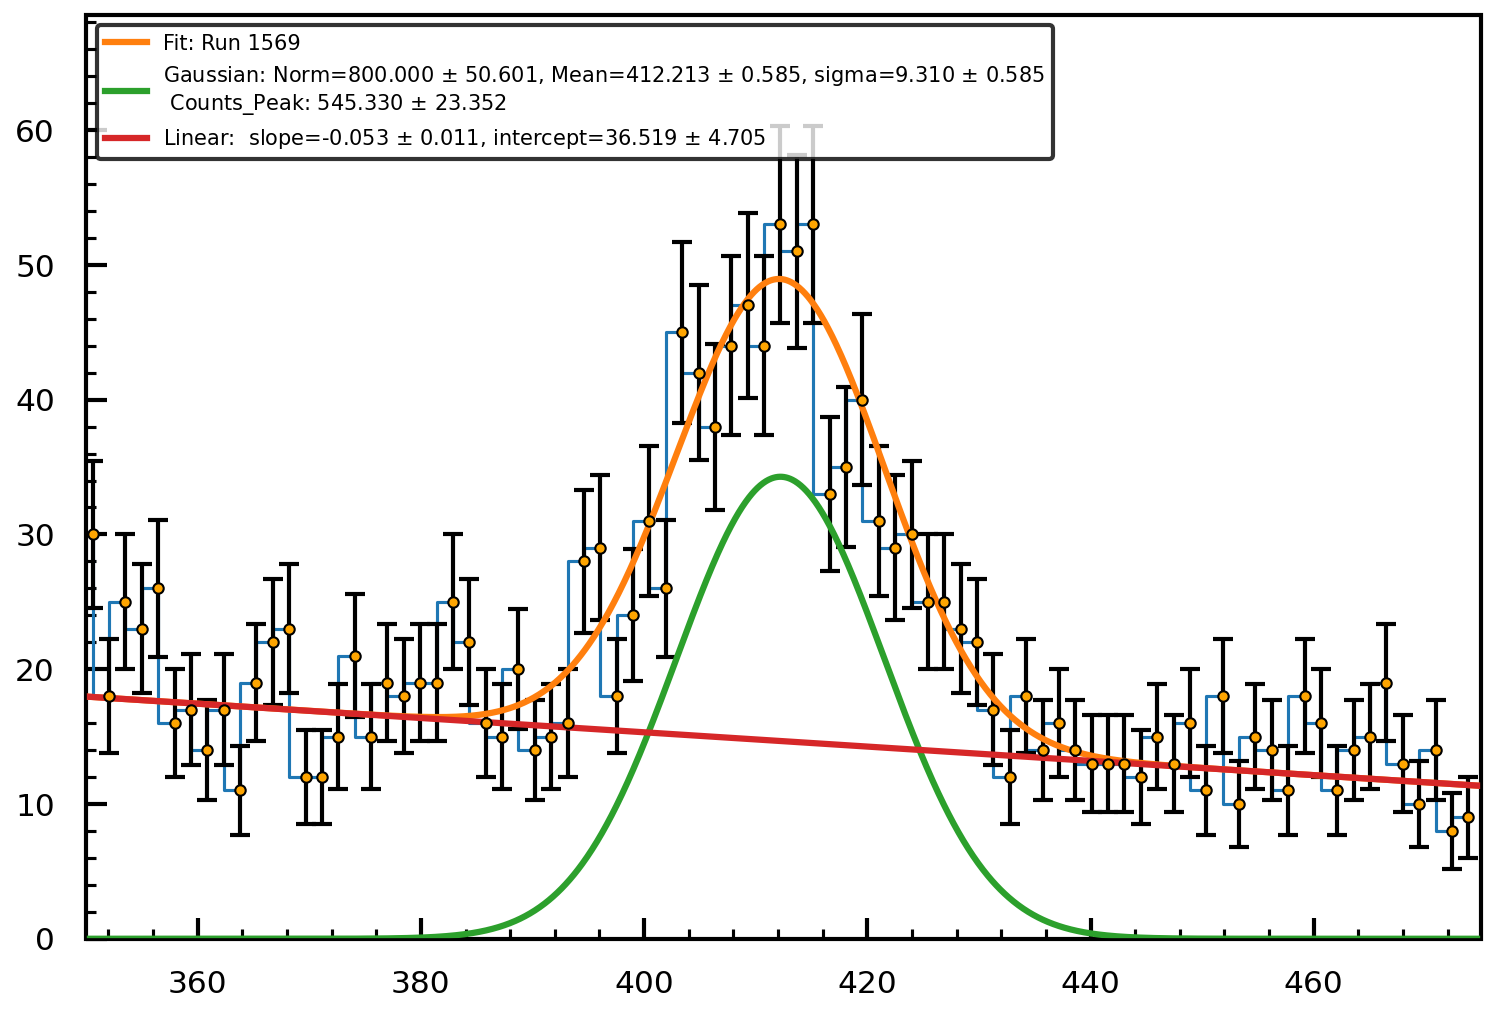

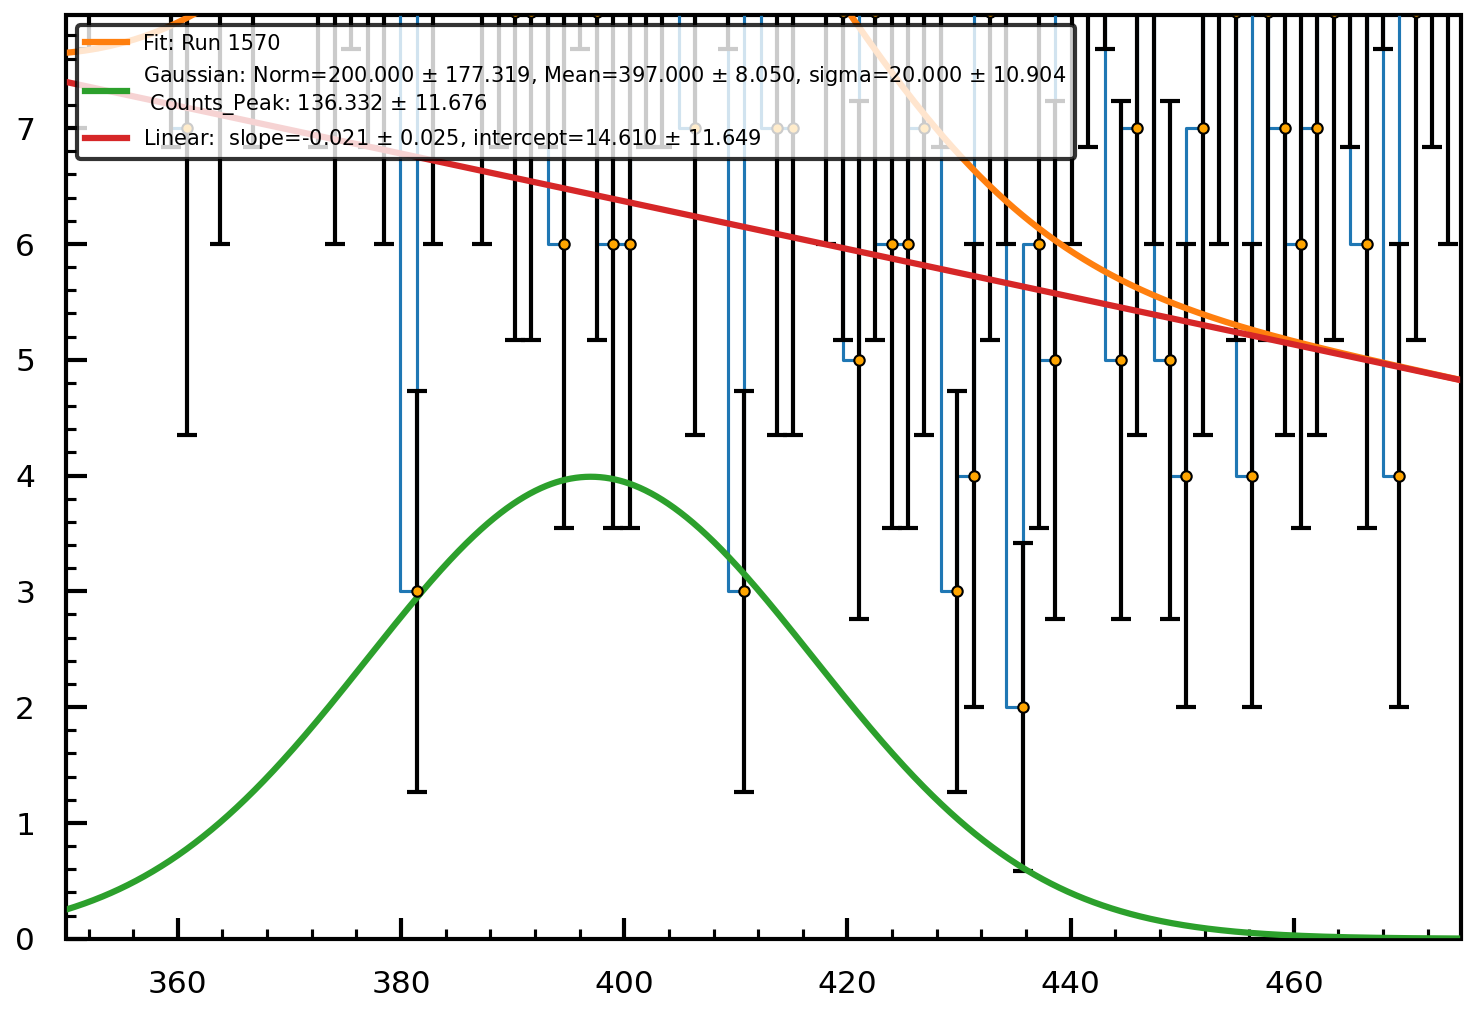

In [16]:
Counts_peak_gauss = []
dCounts_peak_gauss = []
for i in range(len(runNumber)):
    datafile = np.loadtxt("/Users/shahinashahina/Documents/PhD/Experiments/25Mg(a,n)/CAMPAIGN_2021/25Mg_CAMPAIGN_2021/Data/25Mgan_Nov_Dec_2021_CeBr3/run_%s.mpa" %(runNumber[i]), skiprows=323)
    y_data = datafile
    y_data_err = np.sqrt(y_data)
    caloff=-4.567830
    calfact=1.467560
    x = list(range(8192))
    x_cal = (np.array(x))*calfact +  caloff
    binwidth = (8192*calfact + caloff)/(8192)
    E_min = 350
    E_max = 475
    # Masking in the energy range of interest 
    mask1 = x_cal > E_min
    x_cal_m1 = x_cal[mask1]
    y_data_m1 = y_data[mask1]
    y_data_err_m1 = y_data_err[mask1]

    mask2 = x_cal_m1 < E_max
    x_cal_m2 = x_cal_m1[mask2]
    y_data_m2 = y_data_m1[mask2]
    y_data_m2_err = y_data_err_m1[mask2]
    # Fitting Parameters
    norm_min=np.min(y_data_m2)*100
    norm_max=np.max(y_data_m2)*100
    mean_min= 417-20
    mean_max= 417 +20 
    sigma_min=0
    sigma_max=20
    slope_min = -10
    intercept_min = -1000
    slope_max = 10
    intercept_max = 1000
    #Matplotlib figure details 
    fig,ax=plt.subplots(1,1,figsize=(20,20))
    fig.set_dpi(150)
    fig.set_size_inches(12,8)

    #Axis ticks 
    ax.tick_params(which='major', direction='in', width=2, length=10, color='k', pad=15)
    ax.tick_params(which='minor', direction='in', width=1.5, length=5, color='k', pad=15)
    ax.xaxis.set_minor_locator(mtick.AutoMinorLocator(5))
    ax.yaxis.set_minor_locator(mtick.AutoMinorLocator(5))
    ax.tick_params(labelsize=15)
    ax.patch.set_edgecolor('k')
    ax.patch.set_linewidth(2) 


    popt, pcov = curve_fit(fitFunc_1,x_cal_m2,y_data_m2,bounds=([norm_min,mean_min,sigma_min,slope_min,intercept_min],[norm_max,mean_max,sigma_max,slope_max,intercept_max]),sigma=y_data_m2_err) 


    x = np.linspace(E_min, E_max, 2000)
    y = fitFunc_1(x, *popt)
    perr =  np.sqrt(np.diag(pcov))
    y1 = gaussian1(x,popt[0],popt[1],popt[2])
    #y2 = quadratic(x,popt[3],popt[4],popt[5])
    y2 = linear(x,popt[3],popt[4])


    Counts_Peak = popt[0]/(binwidth)
    Counts_peak_gauss.append(Counts_Peak)
    dCounts_peak_gauss.append(np.sqrt(Counts_Peak))


    plt.step(x_cal_m2,y_data_m2)
    ax.errorbar(x_cal_m2,y_data_m2,y_data_m2_err,fmt='o',color="orange",ms=5,ecolor='k',solid_capstyle='projecting', capsize=5,capthick=2,elinewidth=2,markeredgecolor="k")
    plt.plot(x,y,label="Fit: Run %d" %(runNumber[i]),linewidth=3)
    plt.plot(x,y1,label="Gaussian: Norm=%5.3f $\\pm$ %5.3f, Mean=%5.3f $\\pm$ %5.3f, sigma=%5.3f $\\pm$ %5.3f\n Counts_Peak: %5.3f $\\pm$ %5.3f"%(popt[0],perr[0],popt[1],perr[1],popt[2],perr[2],Counts_Peak,np.sqrt(Counts_Peak)),linewidth=3)
    plt.plot(x,y2,label="Linear:  slope=%5.3f $\\pm$ %5.3f, intercept=%5.3f $\\pm$ %5.3f " %(popt[3],perr[3],popt[4],perr[4]),linewidth=3)
    plt.xlim(E_min,E_max)
    plt.ylim(0,(2*popt[0])/(popt[2]*np.sqrt(2*np.pi)))

    #Legend Properties 
    legend_properties = {'size':10}
    leg =plt.legend(fontsize=10,loc=2)
    leg.get_frame().set_edgecolor('k')
    leg.get_frame().set_linewidth(2.0)

    plt.show()





In [17]:
Yield = Counts_peak_gauss/(Charge)
dYield = dCounts_peak_gauss/(Charge)


In [18]:
Energy

array([809.8835707 , 804.97144718, 801.21354016, 799.04713723,
       797.24198231, 794.93288204, 792.79963775, 791.11233915,
       788.71380972, 786.50301465, 784.6998337 , 782.83749626,
       781.33209284, 779.96257928, 778.80187993, 777.60543258,
       776.44648911, 775.84905613, 775.2640386 , 774.75232926])

In [19]:
# Target thickness from the 2018 measurement 
energy_old = np.array([789.8712072289609, 789.6251414338092,
                    789.0101446570768, 788.0266481559996,
                    786.6753419421544, 786.0614951847172,
                    786.0614951847172, 785.2025122310582, 783.118365804974,
                    782.0161154364476, 781.5264755546164,
                    781.0369890086916, 780.3030466946276,
                    780.0584759245595, 779.4472167105359,
                    779.0805761840511, 778.5918563176562,
                    777.9811721132801, 777.370727496257, 777.004575727973,
                    776.6385102111356, 775.906637931803, 775.5408311693071,
                    774.9313449016968, 774.56576814306])
yield_old = np.array([np.nan,
                    0.011976047904191616, 0.010649730368190223,
                    0.018147023888082352, 0.02887961532352389, np.nan,
                    0.02147832223620018, 0.06922257720979764,
                    0.2215644527531114, 0.39347847520368556,
                    0.4911491785000137, 0.5653531973616851,
                    0.6351313583007266, 0.6673846642772646,
                    0.6622456063429427, 0.6872370266479664,
                    0.6862059799356127, 0.7174690508940853,
                    0.6743186825224875, 0.6770069167889331,
                    0.6684796912009825, 0.6943051695651759,
                    0.7502537204427541, 0.013859907138622172,
                    0.012946761348032482])
dyield_old_err = np.array([np.nan,
                    0.003321558061228916, 0.003211014522703676,
                    0.005471533572580506, 0.0064576783027443995, np.nan,
                    0.0057403230750421, 0.009599444290372707,
                    0.013847778297069463, 0.01877970299971942,
                    0.021274032455681748, 0.020480585447485603,
                    0.021065977405926962, 0.02427254556907346,
                    0.024595184365223902, 0.025349119610520728,
                    0.025991904900798606, 0.028098256582786692,
                    0.02864905557880599, 0.02663648087851359,
                    0.024216464149210033, 0.025750353384547196,
                    0.0266759513054514, 0.0016334057207225959,
                    0.002253741867683325])

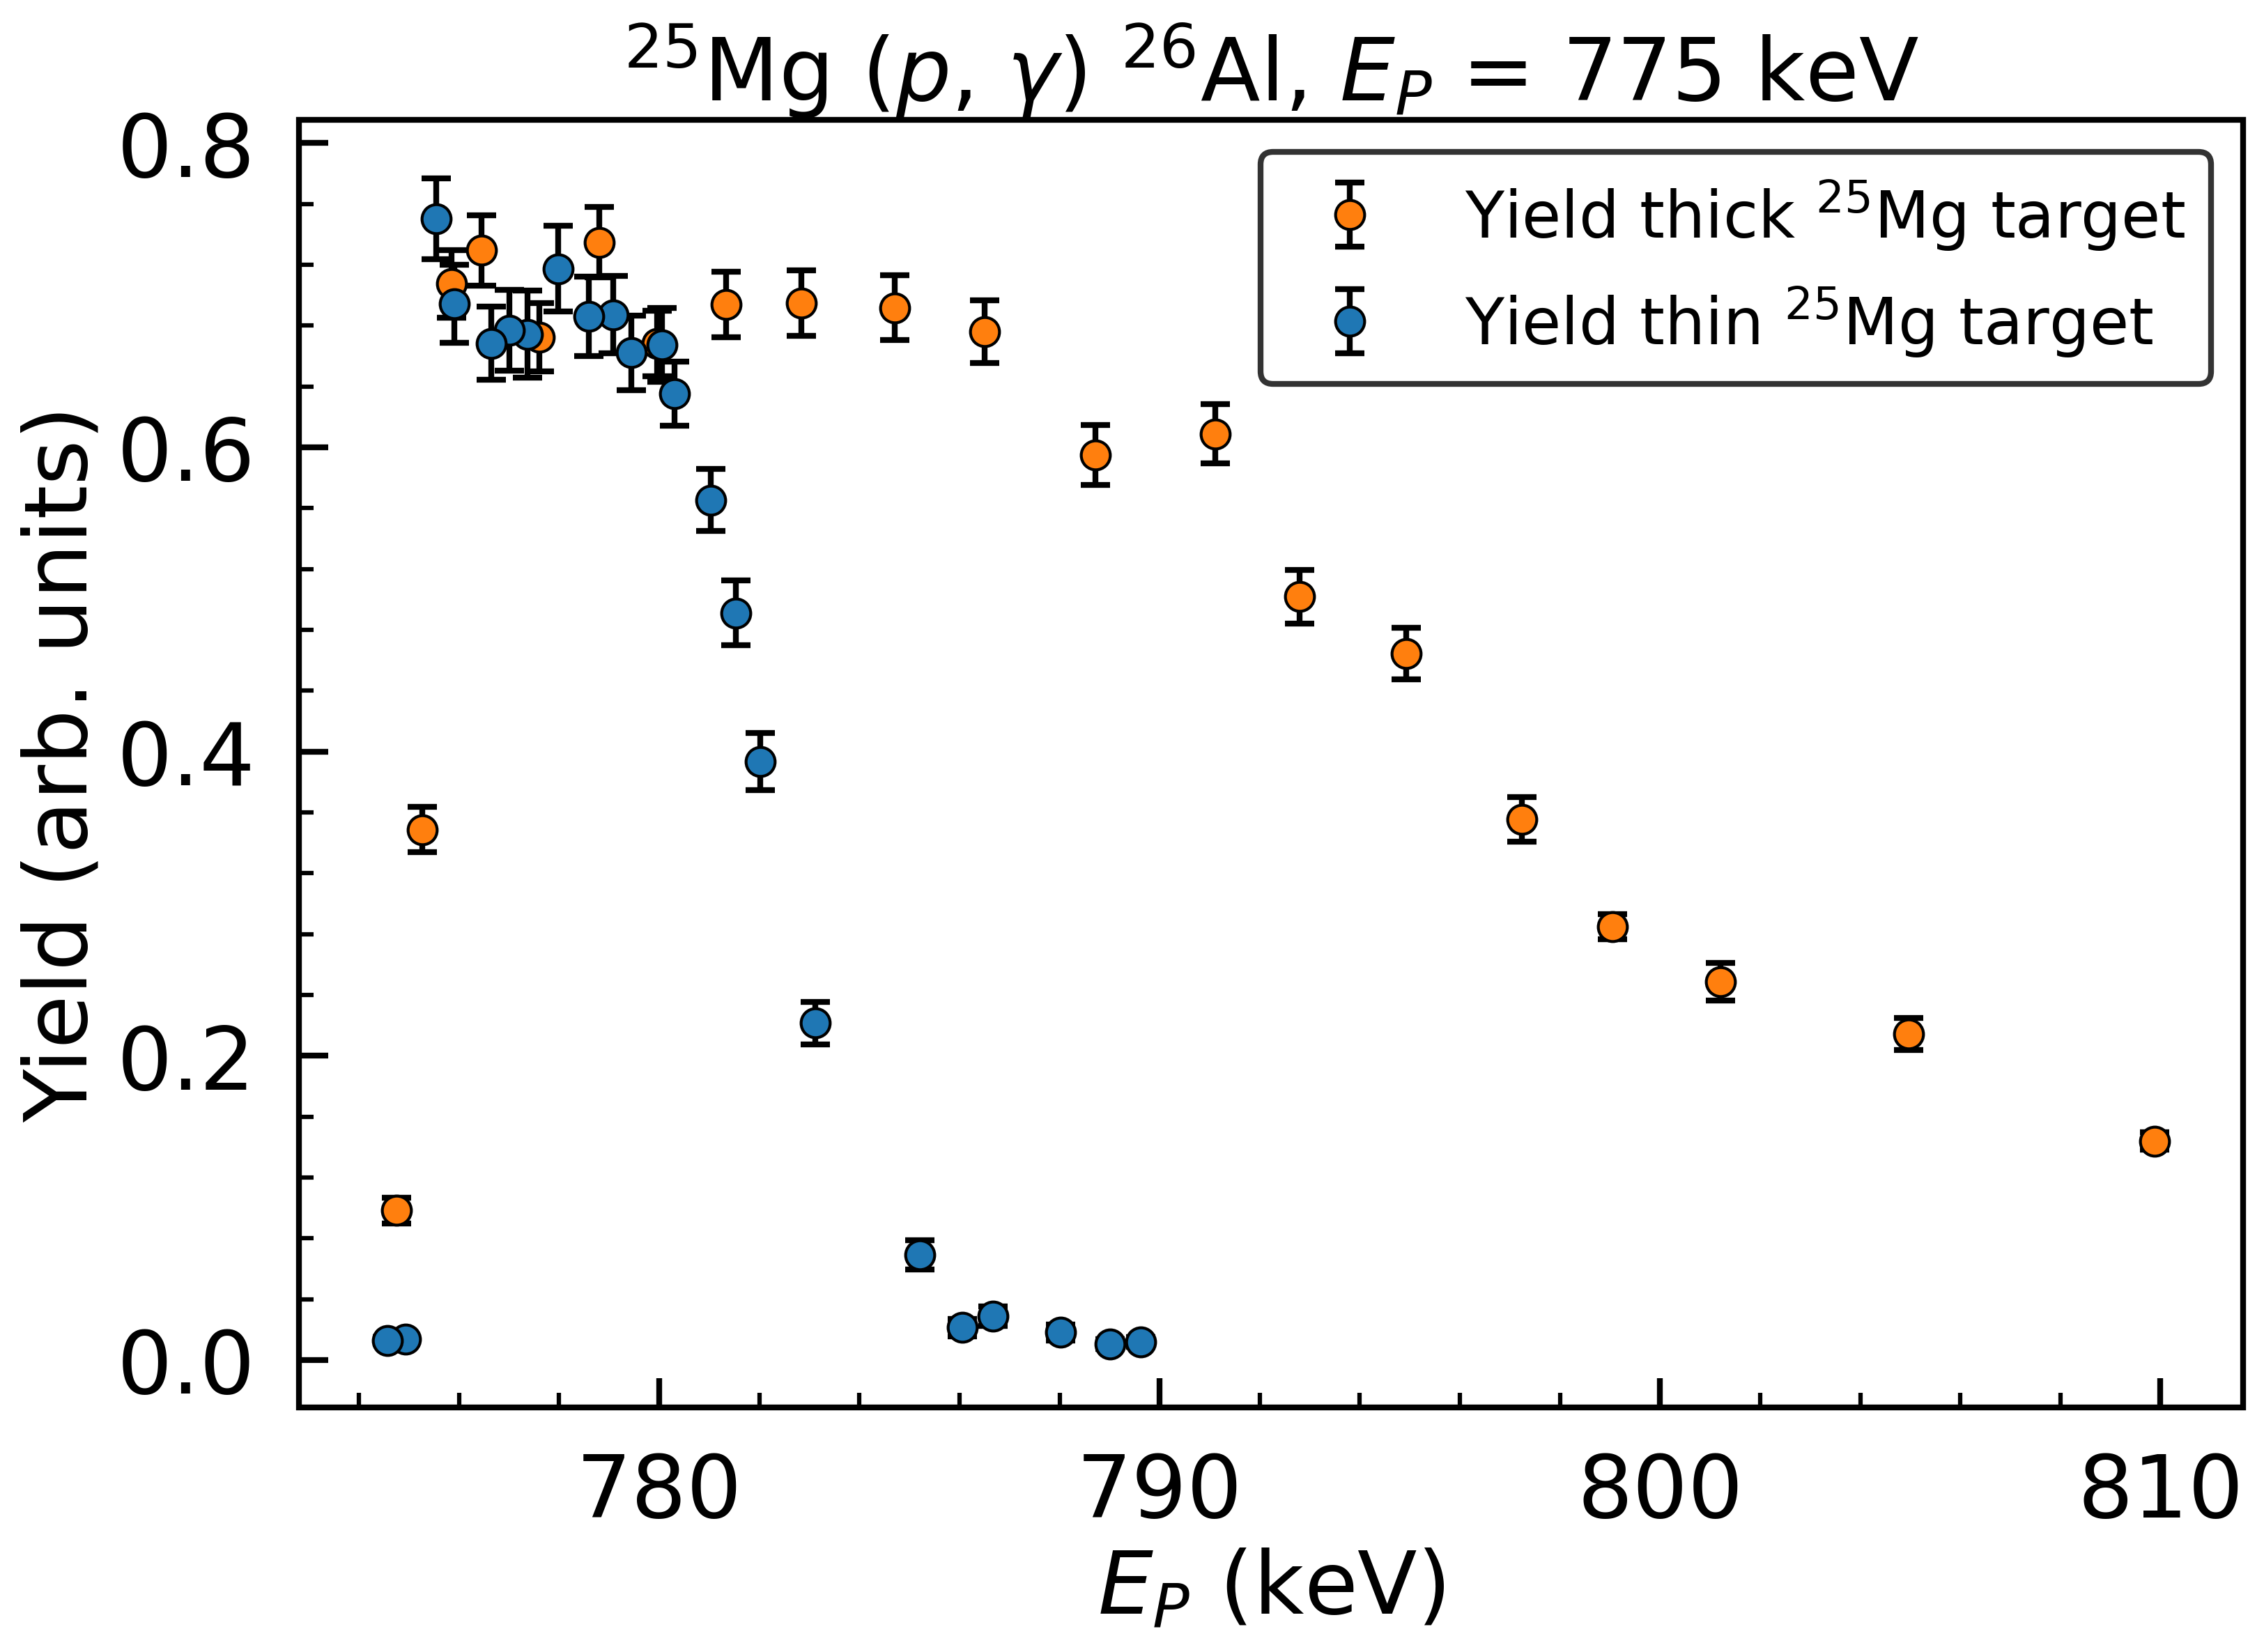

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Assuming you have data for both series: Energy, Yield, dYield, energy_old, yield_old, dyield_old_err

#fig, ax1 = plt.subplots(1, 1, figsize=(10, 8), dpi=150)
fig, ax1 = plt.subplots(figsize=(8, 8 * 0.75))
fig.set_dpi(300)
fig.set_size_inches(12, 8)

#Axis ticks 
ax1.tick_params(which='major', direction='in', width=2, length=10, color='k', pad=15)
ax1.tick_params(which='minor', direction='in', width=1.5, length=5, color='k', pad=15)
ax1.xaxis.set_minor_locator(mtick.AutoMinorLocator(5))
ax1.yaxis.set_minor_locator(mtick.AutoMinorLocator(5))
ax1.tick_params(labelsize=30)
ax1.patch.set_edgecolor('k')
ax1.patch.set_linewidth(2)

# Plotting the first data series
ax1.errorbar(Energy, Yield*25, dYield*25, fmt='o', color="tab:orange", ms=10, ecolor='k', solid_capstyle='projecting', capsize=5, capthick=2, elinewidth=2, markeredgecolor='k', label="Yield thick ${}^{25}$Mg target")

# Plotting the second data series on the same axes
ax1.errorbar(energy_old, yield_old, dyield_old_err, fmt='o', color="tab:blue", ms=10, ecolor='k', solid_capstyle='projecting', capsize=5, capthick=2, elinewidth=2, markeredgecolor='k', label="Yield thin ${}^{25}$Mg target")

# Legend Properties 
leg1 = ax1.legend(fontsize=22, loc="upper right")
leg1.get_frame().set_edgecolor('k')
leg1.get_frame().set_linewidth(2.0)

ax1.set_ylabel("Yield (arb. units)", fontsize=30)
ax1.set_xlabel("$E_P$ (keV)", fontsize=30)
plt.title('${}^{25}$Mg ($p$, $\gamma$) ${}^{26}$Al, $E_{P}$ = 775 keV ', fontsize=30)
plt.savefig("25Mg_target_thickness_thin.png",dpi=300,bbox_inches='tight')
plt.show()


In [41]:
pwd

'/Users/shahinashahina/Documents/PhD/Experiments/25Mg(a,n)/CAMPAIGN_2021/25Mg_CAMPAIGN_2021/Target_thickness'

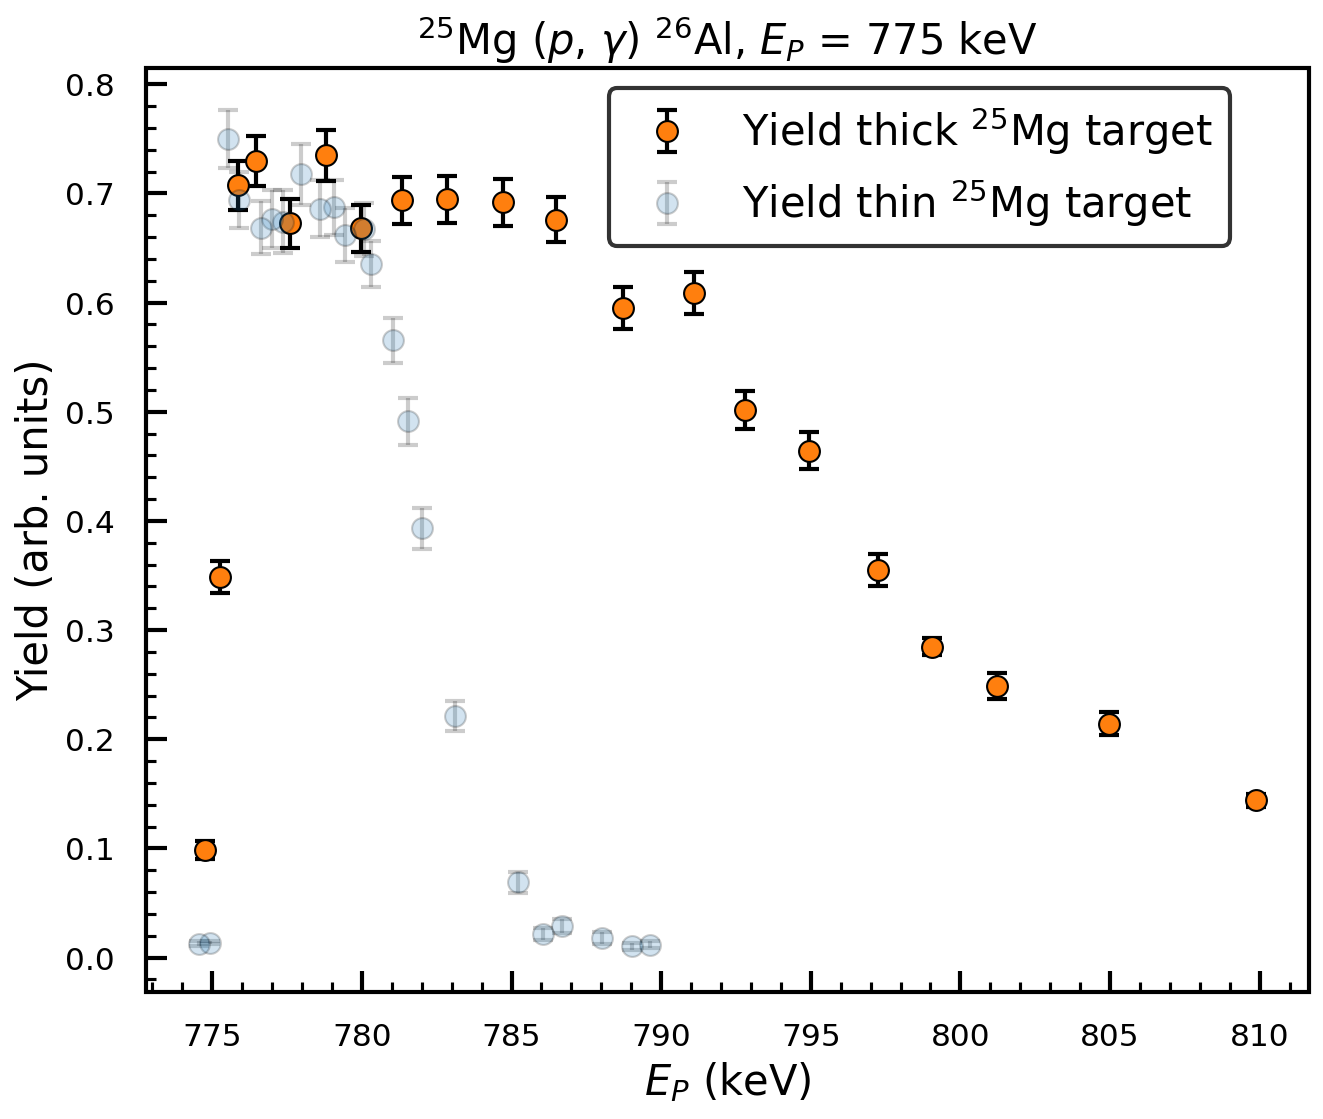

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Assuming you have data for both series: Energy, Yield, dYield, energy_old, yield_old, dyield_old_err

fig, ax1 = plt.subplots(1, 1, figsize=(10, 8), dpi=150)

# Axis ticks
ax1.tick_params(which='major', direction='in', width=2, length=10, color='k', pad=15)
ax1.tick_params(which='minor', direction='in', width=1.5, length=5, color='k', pad=15)
ax1.xaxis.set_minor_locator(mtick.AutoMinorLocator(5))
ax1.yaxis.set_minor_locator(mtick.AutoMinorLocator(5))
ax1.tick_params(labelsize=15)
ax1.patch.set_edgecolor('k')
ax1.patch.set_linewidth(2)

# Scaling factor for thick target yield
thick_scaling_factor = 25

# Plotting the first data series (thick target) with blurred points
ax1.errorbar(Energy, Yield * thick_scaling_factor, dYield * thick_scaling_factor, fmt='o', color="tab:orange", ms=10, ecolor='k', solid_capstyle='projecting', capsize=5, capthick=2, elinewidth=2, markeredgecolor='k', label="Yield thick ${}^{25}$Mg target")

# Plotting the second data series (thin target) on the same axes
ax1.errorbar(energy_old, yield_old, dyield_old_err, fmt='o', color="tab:blue", ms=10, ecolor='k', solid_capstyle='projecting', capsize=5, capthick=2, elinewidth=2, markeredgecolor='k', alpha=0.2,label="Yield thin ${}^{25}$Mg target")

# Legend Properties
leg1 = ax1.legend(fontsize=20, bbox_to_anchor=(0.95, 1), loc="upper right")
leg1.get_frame().set_edgecolor('k')
leg1.get_frame().set_linewidth(2.0)

ax1.set_ylabel("Yield (arb. units)", fontsize=20)
ax1.set_xlabel("$E_P$ (keV)", fontsize=20)
plt.title('${}^{25}$Mg ($p$, $\gamma$) ${}^{26}$Al, $E_{P}$ = 775 keV ', fontsize=20)
plt.savefig("25Mg_target_thickness_thick.png",dpi=300)
plt.show()


In [22]:
Yield[4]

0.014216040064027512

In [23]:
Yield[18]

0.013952404073182332

In [24]:
dE_45 = Energy[4] - Energy[18]

In [25]:
dE_45 # this is in keV 
dE_45 = dE_45*10**(3)

In [26]:
dE_45

21977.943712516095

In [27]:
dE_0 = dE_45*np.sin(np.pi/4.0)

In [28]:
dE_0

15540.753035656375

In [29]:
dE_dx_Mg =   8.306 # From SRIM at 775 KeV Units: eV/1E15 atoms/cm^2
dE_dx_O =    6.265 

In [30]:
#Calculating the number of target nuclei
N_t_1 =  (dE_0)/(dE_dx_Mg) # atoms/cm^2

In [31]:
N_t = N_t_1*10**(15)

In [32]:
(N_t*(25))/(6.023*10**(23))*10**(6)

77.6617688001855